## MODEL DEVELOPMENT

In [3]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import gaussian_kde
import sys

BASE          = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"
sys.path.insert(0, str(BASE))

with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN    = stats_data["hr"]["mean"]
HR_STD     = stats_data["hr"]["std"]
LR_MEAN    = stats_data["lr"]["mean"]
LR_STD     = stats_data["lr"]["std"]
DATA_RANGE = stats_data["hr_data_range"]
DATA_MIN   = stats_data["hr_percentiles"]["p1"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [23]:
import importlib
import scripts.models.realesrgan as realesrgan

importlib.reload(realesrgan)

from scripts.models.realesrgan import RealESRGANModule


MODEL_PATH  = str(BASE / "checkpoints/gan_final/exp_1784030832_epoch=47_val_water_mae=0.9792.ckpt")
model = RealESRGANModule.load_from_checkpoint(MODEL_PATH, strict=False).to(device).eval()

# checkpoints/gan_final/exp_1784030832_epoch=47_val_water_mae=0.9792.ckpt #tuned
# checkpoints/gan_final/exp2_fixed_lr_schedule_epoch=56_val_water_mae=0.8773.ckpt #spade

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


/share/home/e2406751/Superresolution-TIR/scripts/models/realesrgan.py:308: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location="cpu")
/share/h

[INFO] generator loaded 702 params
[INFO] discriminator loaded 28 params


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_

In [5]:
from scripts.utils.dataset import SRDataset

val_ds = SRDataset(
    split="val",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,                
    aux_dir=str(PATCHES_DIR / "val" / "AUX"),
    transform=None,
)

print(f"val set size: {len(val_ds)} samples")

np.random.seed(42)  # For reproducibility
N_SAMPLES   = 5
vis_indicesv = np.random.choice(len(val_ds), N_SAMPLES, replace=False)
vis_samplesv = [val_ds[i] for i in vis_indicesv]
print(f"\nSelected tiles for viz: {[s['fname'] for s in vis_samplesv]}")

val set size: 43 samples



Selected tiles for viz: ['PDR_2023_b2_r2048_c512.npy', 'DZM_2023_b2_r2560_c0.npy', 'DZM_2023_b2_r2816_c0.npy', 'PDR_2014_b1_r1792_c512.npy', 'PDR_2014_b1_r1280_c256.npy']


In [5]:
from scripts.utils.dataset import SRDataset
test_ds = SRDataset(
    split="test",  # Pointing to the test set
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,
    aux_dir=str(PATCHES_DIR / "test" / "AUX"),
    transform=None,
)

# np.random.seed(42)  # For reproducibility
np.random.seed(42)  # For reproducibility
N_SAMPLES   = 10
vis_indicest = np.random.choice(len(test_ds), N_SAMPLES, replace=False)
vis_samplest = [test_ds[i] for i in vis_indicest]
print(f"\nSelected tiles for viz: {[s['fname'] for s in vis_samplest]}")


Selected tiles for viz: ['BRC_2022_b0_r1280_c768.npy', 'HAUT_2025_b0_r4864_c1792.npy', 'BRC_2023_b0_r256_c0.npy', 'BRC_2022_b0_r0_c0.npy', 'HAUT_2025_b0_r1536_c3840.npy', 'HAUT_2025_b0_r3840_c3328.npy', 'BRC_2022_b0_r768_c512.npy', 'HAUT_2025_b0_r2560_c3584.npy', 'BRC_2023_b0_r0_c0.npy', 'HAUT_2025_b0_r4096_c3072.npy']


In [6]:
def prep_sample(sample):
    """
    Extracts, denormalizes, and masks all geospatial fields 
    from a validation sample to prepare them for plotting.
    """
    hr_mask = sample["hr_mask"].squeeze().numpy()
    valid = hr_mask > 0.5
    
    # 1. Denormalize and mask LR Input (Upsampled 4x via Kronecker repeat)
    lr_64 = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.where(valid, np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1), np.nan)
    
    # 2. Denormalize and mask HR Ground Truth
    hr_np = np.where(valid, sample["hr"][0].numpy() * HR_STD + HR_MEAN, np.nan)
    
    # 3. Compute stable robust min/max bounds from valid pixels only
    valid_pixels = hr_np[np.isfinite(hr_np)]
    vmin = np.percentile(valid_pixels, 1) if len(valid_pixels) > 0 else 24.0
    vmax = np.percentile(valid_pixels, 99) if len(valid_pixels) > 0 else 28.0
    
    return lr_256, hr_np, valid, vmin, vmax


def run_inference(model_obj, sample):
    """Prepares full multi-scale batch for the network forward pass"""
    batch = {
        "lr": sample["lr"].unsqueeze(0).to(device),
        "aux_lr": sample["aux_lr"].unsqueeze(0).to(device),
        "aux_mid": sample["aux_mid"].unsqueeze(0).to(device),
        "aux_hr": sample["aux_hr"].unsqueeze(0).to(device),
        "time_channels": sample["time_channels"].unsqueeze(0).to(device),
        "time_gap_hours": sample["time_gap_hours"].unsqueeze(0).to(device),
        "date_gap_days": sample["date_gap_days"].unsqueeze(0).to(device),
    }
    with torch.no_grad():
        sr = model_obj(batch)
    return (sr[:, 0] * HR_STD + HR_MEAN).squeeze().cpu().numpy()


### Custom Loss

In [ ]:
TARGET_TILES = ["HAUT_2025_b0_r1792_c3840.npy"]
# HAUT_2025_b0_r4608_c1536.npy #initial sample

samples = []
for idx in range(len(test_ds)):
    # Check if target name matches (handles with or without .npy extension)
    current_fname = str(test_ds[idx]["fname"])
    if any(target in current_fname for target in TARGET_TILES):
        samples.append(test_ds[idx])

if not samples:
    raise ValueError(f"None of the target tiles {TARGET_TILES} were found in test_ds!")

print(f"Selected tiles: {[s['fname'] for s in samples]}")


Selected tiles: ['HAUT_2025_b0_r1792_c3840.npy']


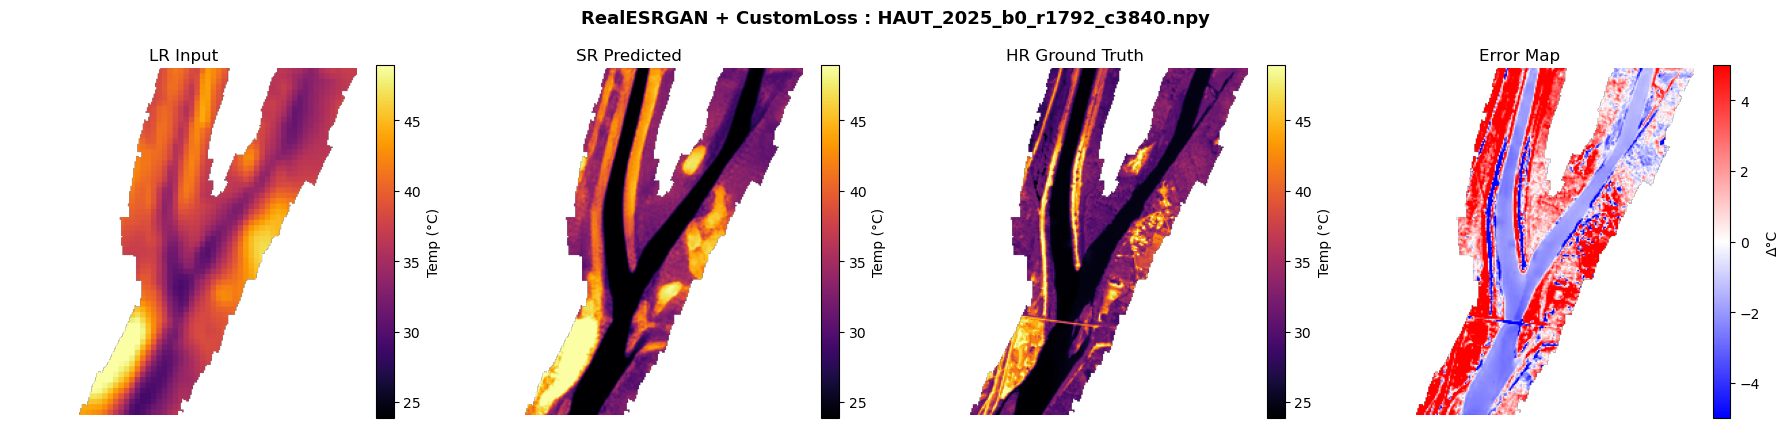

In [8]:
for sample in samples:
    fname = sample["fname"]
    MODEL_LABEL = f"RealESRGAN + CustomLoss : {fname}"
    # Cleanly unpack all prepared arrays and scale thresholds
    lr_256, hr_np, valid, vmin, vmax = prep_sample(sample)
    
    # 1. Run the model forward pass
    raw_sr = run_inference(model, sample)
    
    # 2. THE FIX: Explicitly mask out the background pixels on the SR prediction
    # This prevents unconstrained background noise from spilling into your plots
    sr_np = np.where(valid, raw_sr, np.nan)
    
    # 3. Compute residual map strictly over mutually valid space
    residual = sr_np - hr_np

    # Isolate valid residuals for a tightly scaled, symmetrical error map
    valid_res = residual[np.isfinite(residual)]
    res_lim = np.percentile(np.abs(valid_res), 98) if len(valid_res) > 0 else 3.0

    # Setup 4-panel visual inspector grid
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(f"{MODEL_LABEL}", fontsize=13, fontweight="bold")

    # Panel 0: Low-Res Input
    im_lr = axes[0].imshow(lr_256, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR Input"); axes[0].axis("off")
    plt.colorbar(im_lr, ax=axes[0], fraction=0.046, label="Temp (°C)")
    
    # Panel 1: Model Prediction
    im_sr = axes[1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR Predicted"); axes[1].axis("off")
    plt.colorbar(im_sr, ax=axes[1], fraction=0.046, label="Temp (°C)")
    
    # Panel 2: Ground Truth Target
    im_hr = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR Ground Truth"); axes[2].axis("off")
    plt.colorbar(im_hr, ax=axes[2], fraction=0.046, label="Temp (°C)")
    
    # Panel 3: Spatial Residual Errors
    im_res = axes[3].imshow(residual, cmap="bwr", vmin=-5, vmax=5)
    axes[3].set_title("Error Map"); axes[3].axis("off")
    plt.colorbar(im_res, ax=axes[3], fraction=0.046, label="Δ°C")

    plt.tight_layout()
    plt.show()

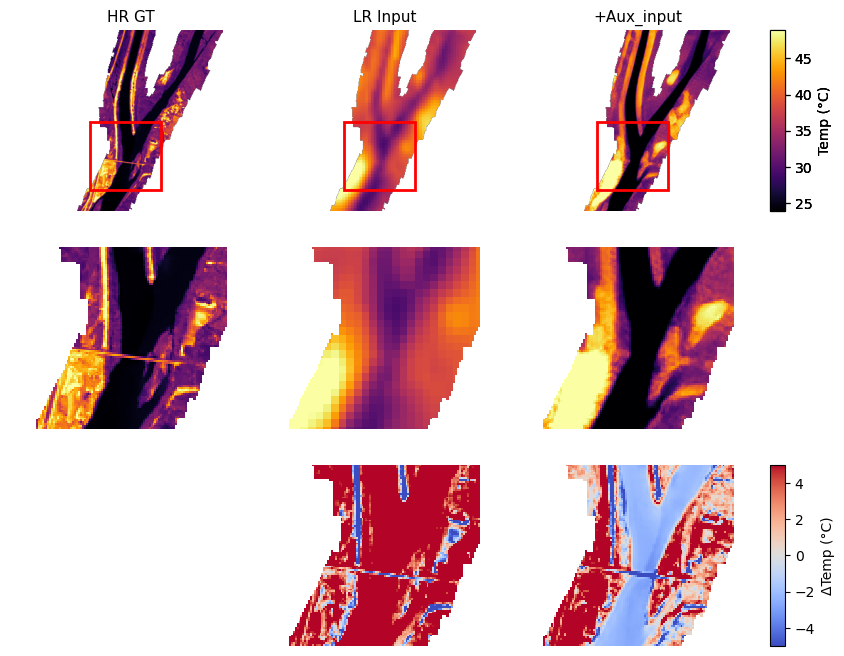

In [24]:
import os
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom  # or use cv2.resize / torchvision

# --- DEFINE YOUR BOX IN PIXELS ---
x, y, w, h = 70, 130, 100, 95  # top-left corner + size
row_slice = slice(y, y + h)  # derive slices once, reuse everywhere
col_slice = slice(x, x + w)

COL_LABELS = ["HR GT", "LR Input", "+Aux_input"] 

def add_zoom_box(ax, x, y, w, h, color="red", lw=2):
    ax.add_patch(
        mpatches.Rectangle(
            (x, y), w, h, linewidth=lw, edgecolor=color, facecolor="none"
        )
    )

for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # --- 1. UPSAMPLE LR TO HR RESOLUTION (if not already 256x256) ---
    if lr_np.shape != hr_np.shape:
        zoom_factors = (
            hr_np.shape[0] / lr_np.shape[0],
            hr_np.shape[1] / lr_np.shape[1],
        )
        lr_bicubic = zoom(lr_np, zoom_factors, order=3)  # order=3 is bicubic
    else:
        lr_bicubic = lr_np.copy()

    # Mask bicubic LR image
    lr_bicubic_masked = np.where(hr_mask > 0.5, lr_bicubic, np.nan)

    # --- 2. CALCULATE MODEL MAPS & RESIDUALS ---
    sr_maps, residuals = {}, {}

    # Calculate Bicubic Residual first
    residuals_ = np.where(hr_mask > 0.5, lr_bicubic_masked - hr_np, np.nan)

    sr_np = run_inference(model, sample)
    sr_np = np.where(hr_mask > 0.5, sr_np, np.nan)
    # sr_maps[model] = sr_np
    residuals = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)

    full_panels = [hr_np, lr_bicubic_masked, sr_np] 

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(
        3,
        4,
        width_ratios=[1, 1, 1, 0.06],
        hspace=0.2,
        wspace=0.06,
        figure=fig,
    )


    # Row 0: Full Patches
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[0, c])
        temp_im = ax.imshow(arr, cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis("off")
        add_zoom_box(ax, x, y, w, h)
        fig.colorbar(temp_im, cax=fig.add_subplot(gs[0, 3]), label="Temp (°C)")

    # Row 1: Zoomed Crops
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[1, c])
        ax.imshow(
            arr[row_slice, col_slice],
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.axis("off")

    # Row 2: Error Maps
    # Column 0: Blank under HR (HR - HR = 0)
    fig.add_subplot(gs[2, 0]).axis("off")

    # Column 1: LR / Bicubic Residual
    ax_lr_err = fig.add_subplot(gs[2, 1])
    err_im = ax_lr_err.imshow(
        residuals_[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax_lr_err.axis("off")

    # Columns 2+: Model Residuals
    ax = fig.add_subplot(gs[2, 2 + 0])
    err_im = ax.imshow(
        residuals[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax.axis("off")
    fig.colorbar(err_im, cax=fig.add_subplot(gs[2, 3]), label="ΔTemp (°C)")

    # --- 4. SAVE FIGURE ---
    plt.savefig(
        "custom_loss.png", transparent=True, dpi=600, bbox_inches="tight", pad_inches=0
    )
    plt.show()
    plt.close(fig)  # Prevents notebook memory leaks across loops

### SPADE

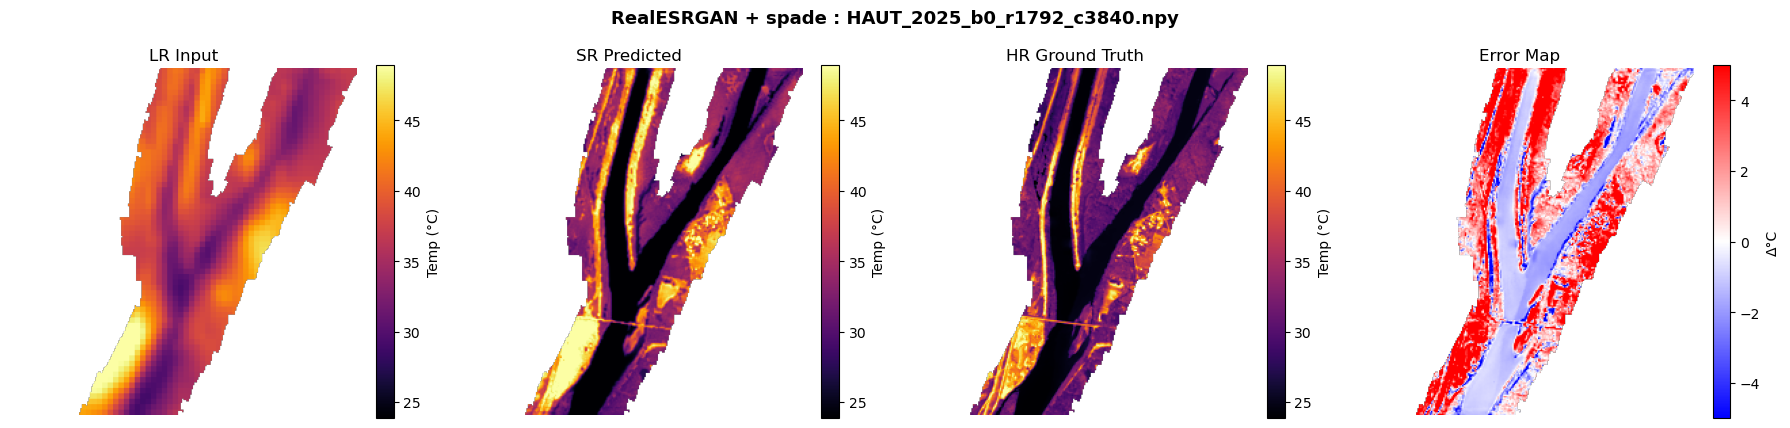

In [13]:
# with spade 
for sample in samples:
    fname = sample["fname"]
    MODEL_LABEL = f"RealESRGAN + spade : {fname}"
    # Cleanly unpack all prepared arrays and scale thresholds
    lr_256, hr_np, valid, vmin, vmax = prep_sample(sample)
    
    # 1. Run the model forward pass
    raw_sr = run_inference(model, sample)
    
    # 2. THE FIX: Explicitly mask out the background pixels on the SR prediction
    # This prevents unconstrained background noise from spilling into your plots
    sr_np = np.where(valid, raw_sr, np.nan)
    
    # 3. Compute residual map strictly over mutually valid space
    residual = sr_np - hr_np

    # Isolate valid residuals for a tightly scaled, symmetrical error map
    valid_res = residual[np.isfinite(residual)]
    res_lim = np.percentile(np.abs(valid_res), 98) if len(valid_res) > 0 else 3.0

    # Setup 4-panel visual inspector grid
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(f"{MODEL_LABEL}", fontsize=13, fontweight="bold")

    # Panel 0: Low-Res Input
    im_lr = axes[0].imshow(lr_256, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR Input"); axes[0].axis("off")
    plt.colorbar(im_lr, ax=axes[0], fraction=0.046, label="Temp (°C)")
    
    # Panel 1: Model Prediction
    im_sr = axes[1].imshow(sr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR Predicted"); axes[1].axis("off")
    plt.colorbar(im_sr, ax=axes[1], fraction=0.046, label="Temp (°C)")
    
    # Panel 2: Ground Truth Target
    im_hr = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR Ground Truth"); axes[2].axis("off")
    plt.colorbar(im_hr, ax=axes[2], fraction=0.046, label="Temp (°C)")
    
    # Panel 3: Spatial Residual Errors
    im_res = axes[3].imshow(residual, cmap="bwr", vmin=-5, vmax=5)
    axes[3].set_title("Error Map"); axes[3].axis("off")
    plt.colorbar(im_res, ax=axes[3], fraction=0.046, label="Δ°C")

    plt.tight_layout()
    plt.show()

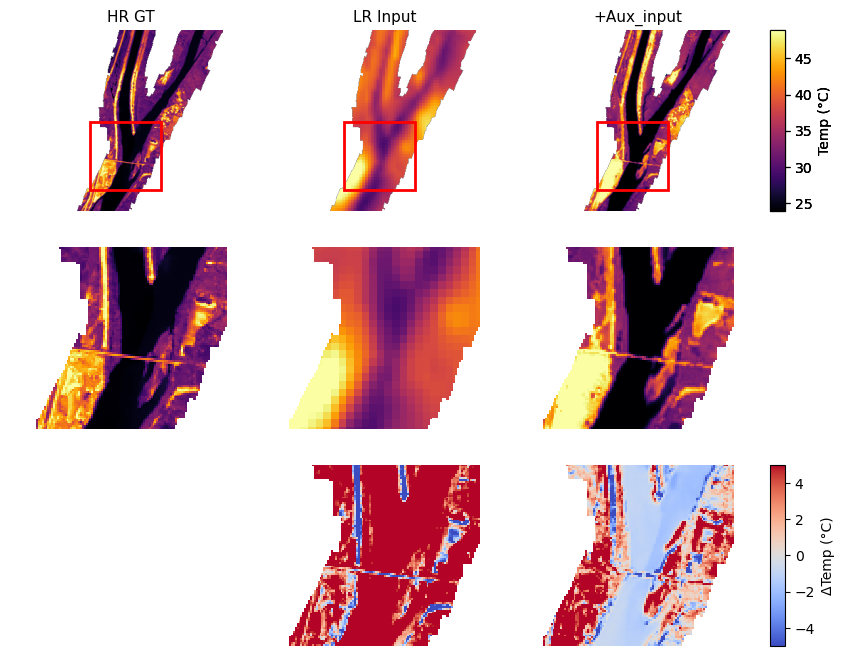

In [22]:
import os
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom  # or use cv2.resize / torchvision

# --- DEFINE YOUR BOX IN PIXELS ---
x, y, w, h = 70, 130, 100, 95  # top-left corner + size
row_slice = slice(y, y + h)  # derive slices once, reuse everywhere
col_slice = slice(x, x + w)

COL_LABELS = ["HR GT", "LR Input", "+Aux_input"] 

def add_zoom_box(ax, x, y, w, h, color="red", lw=2):
    ax.add_patch(
        mpatches.Rectangle(
            (x, y), w, h, linewidth=lw, edgecolor=color, facecolor="none"
        )
    )

for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # --- 1. UPSAMPLE LR TO HR RESOLUTION (if not already 256x256) ---
    if lr_np.shape != hr_np.shape:
        zoom_factors = (
            hr_np.shape[0] / lr_np.shape[0],
            hr_np.shape[1] / lr_np.shape[1],
        )
        lr_bicubic = zoom(lr_np, zoom_factors, order=3)  # order=3 is bicubic
    else:
        lr_bicubic = lr_np.copy()

    # Mask bicubic LR image
    lr_bicubic_masked = np.where(hr_mask > 0.5, lr_bicubic, np.nan)

    # --- 2. CALCULATE MODEL MAPS & RESIDUALS ---
    sr_maps, residuals = {}, {}

    # Calculate Bicubic Residual first
    residuals_ = np.where(hr_mask > 0.5, lr_bicubic_masked - hr_np, np.nan)

    sr_np = run_inference(model, sample)
    sr_np = np.where(hr_mask > 0.5, sr_np, np.nan)
    # sr_maps[model] = sr_np
    residuals = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)

    full_panels = [hr_np, lr_bicubic_masked, sr_np] 

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(
        3,
        4,
        width_ratios=[1, 1, 1, 0.06],
        hspace=0.2,
        wspace=0.06,
        figure=fig,
    )


    # Row 0: Full Patches
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[0, c])
        temp_im = ax.imshow(arr, cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis("off")
        add_zoom_box(ax, x, y, w, h)
        fig.colorbar(temp_im, cax=fig.add_subplot(gs[0, 3]), label="Temp (°C)")

    # Row 1: Zoomed Crops
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[1, c])
        ax.imshow(
            arr[row_slice, col_slice],
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.axis("off")

    # Row 2: Error Maps
    # Column 0: Blank under HR (HR - HR = 0)
    fig.add_subplot(gs[2, 0]).axis("off")

    # Column 1: LR / Bicubic Residual
    ax_lr_err = fig.add_subplot(gs[2, 1])
    err_im = ax_lr_err.imshow(
        residuals_[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax_lr_err.axis("off")

    # Columns 2+: Model Residuals
    ax = fig.add_subplot(gs[2, 2 + 0])
    err_im = ax.imshow(
        residuals[row_slice, col_slice],
        cmap="coolwarm",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax.axis("off")
    fig.colorbar(err_im, cax=fig.add_subplot(gs[2, 3]), label="ΔTemp (°C)")

    # --- 4. SAVE FIGURE ---
    plt.savefig(
        "spade.png", transparent=True, dpi=600, bbox_inches="tight", pad_inches=0
    )
    plt.show()
    plt.close(fig)  # Prevents notebook memory leaks across loops

In [11]:
def extract_pure_water_pixels(dataset, model_obj):
    all_hr, all_lr, all_sr = [], [], []

    for sample in dataset:
        # 1. Use the masks from the sample
        hr_mask = sample["hr_mask"].squeeze()
        water_mask = sample["water_mask"].squeeze()
        
        # 2. Strict spatial intersection
        pure_water = (hr_mask > 0.5) & (water_mask > 0.5)
        if pure_water.sum() < 10: # Threshold: Ignore patches with negligible water
            continue

        # 3. Inference & Denormalization
        # Ensure we are working with the correct device and shapes
        sr_np = run_inference(model_obj, sample) 
        hr_np = (sample["hr"].squeeze().numpy() * HR_STD) + HR_MEAN
        lr_np = (sample["lr"].squeeze().numpy() * LR_STD) + LR_MEAN
        
        # Upscale LR to match SR/HR dimensions
        lr_up = np.repeat(np.repeat(lr_np, 4, axis=0), 4, axis=1)

        # 4. SAFETY CHECK: Filter out potential NaNs or extreme artifacts
        # If your model outputs NaN, force it to 0 before concatenation
        sr_np = np.nan_to_num(sr_np, nan=0.0)

        # 5. Extract and Validate
        all_hr.append(hr_np[pure_water])
        all_lr.append(lr_up[pure_water])
        all_sr.append(sr_np[pure_water])

    return [np.concatenate(all_hr), np.concatenate(all_lr), np.concatenate(all_sr)]

Extracting physical water-only pixels across full validation stack...


Total pure river water pixels loaded for analysis: 440,308


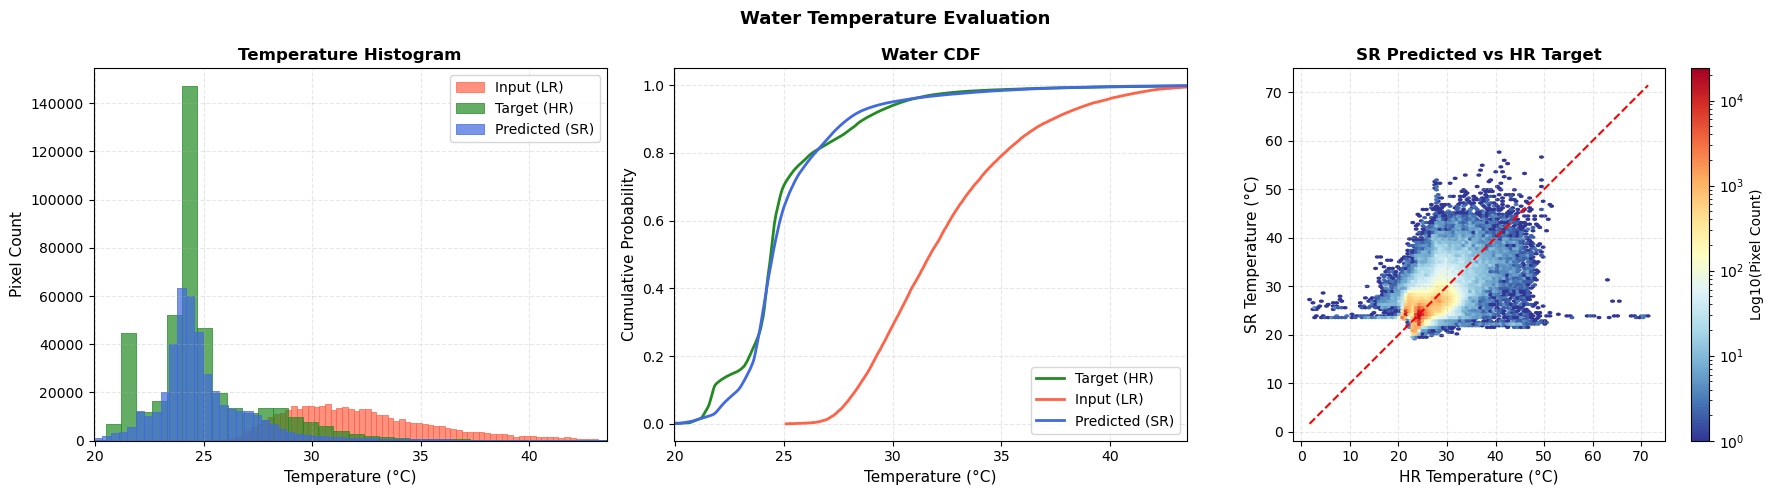

In [13]:
# 1. Cleanly load your flattened physical vectors 
print("Extracting physical water-only pixels across full validation stack...")
hr_v, lr_v, sr_v = extract_pure_water_pixels(test_ds, model)
print(f"Total pure river water pixels loaded for analysis: {len(hr_v):,}")

# --- Common Limits for Histogram and CDF ---
padding = 1.0  
xmin = np.percentile(hr_v, 1) - padding
xmax = np.percentile(lr_v, 99) + padding

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Water Temperature Evaluation", fontsize=13, fontweight="bold")

# Palette setup
palette = {"HR": "forestgreen", "SR": "royalblue", "LR": "tomato"}

# ---------------- Panel 1: Histogram + KDE ----------------
ax_hist = axes[0]
# Plotting order: Input (LR) background, Target (HR) and Predicted (SR) foreground
for vec, key, lbl in [(lr_v, "LR", "Input (LR)"), 
                      (hr_v, "HR", "Target (HR)"), 
                      (sr_v, "SR", "Predicted (SR)")]:
    
    sns.histplot(
        vec,
        ax=ax_hist,
        bins=100,
        stat="count",              # ← Y-axis becomes raw Pixel Count
        kde=False,                  # ← Automatically scales the KDE line to match Pixel Counts!
        color=palette[key],
        label=lbl,
        alpha=0.7,                # Soft bar shading
        edgecolor=palette[key],        
        linewidth=0.5,
        line_kws={"linewidth": 1.0}  # Smooth KDE curve thickness
    )

ax_hist.set_title("Temperature Histogram", fontsize=12, fontweight="bold")
ax_hist.set_xlabel("Temperature (°C)", fontsize=11)
ax_hist.set_ylabel("Pixel Count", fontsize=11)            # Raw pixel count
ax_hist.set_xlim(xmin, xmax)
ax_hist.grid(True, linestyle="--", alpha=0.3)
ax_hist.legend(loc="upper right", frameon=True)

# ---------------- Panel 2: Water CDF ----------------
ax_cdf = axes[1]
for vec, key, lbl in [(hr_v, "HR", "Target (HR)"), 
                      (lr_v, "LR", "Input (LR)"),
                      (sr_v, "SR", "Predicted (SR)")]:
    
    sorted_data = np.sort(vec)
    y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax_cdf.plot(sorted_data, y_values, color=palette[key], lw=2.0, label=lbl)

ax_cdf.set_title("Water CDF", fontsize=12, fontweight="bold")
ax_cdf.set_xlabel("Temperature (°C)", fontsize=11)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=11)
ax_cdf.set_xlim(xmin, xmax) 
ax_cdf.grid(True, linestyle="--", alpha=0.3)
ax_cdf.legend(loc="lower right", frameon=True)

# ---------------- Panel 3: Hexbin (1:1 Scatter) ----------------
ax_scat = axes[2]
hb = ax_scat.hexbin(
    hr_v, sr_v, 
    gridsize=100, 
    cmap="RdYlBu_r", 
    mincnt=1, 
    bins='log'
)

global_min, global_max = min(hr_v.min(), sr_v.min()), max(hr_v.max(), sr_v.max())
ax_scat.plot([global_min, global_max], [global_min, global_max], "r--", lw=1.5)

ax_scat.set_title("SR Predicted vs HR Target", fontsize=12, fontweight="bold")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=11)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=11)
ax_scat.set_aspect("equal")
ax_scat.grid(True, linestyle="--", alpha=0.3)
fig.colorbar(hb, ax=ax_scat, label="Log10(Pixel Count)")

plt.tight_layout()
plt.show()


In [ ]:
def compute_per_campaign_metrics(dataset, model_obj, DATA_RANGE, DATA_MIN):
    from collections import defaultdict
    campaign_data = defaultdict(lambda: {
        "hr_w": [], "sr_w": [], "hr_l": [], "sr_l": [],
        "w_mae": [], "w_rmse": [], "w_psnr": [],
        "l_mae": [], "l_rmse": [], "l_psnr": []
    })
    
    for sample in dataset:
        campaign = "_".join(Path(sample["fname"]).stem.split("_")[:2])
        
        hr_mask    = sample["hr_mask"].squeeze().numpy()
        water_mask = sample["water_mask"].squeeze().numpy()
        valid  = hr_mask > 0.5
        m_w    = valid & (water_mask > 0.5)
        m_nw   = valid & (water_mask < 0.5)
        
        hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN
        sr_np  = run_inference(model_obj, sample)
        sr_np  = np.nan_to_num(sr_np, nan=0.0)
        
        # Per-patch metrics — matches Lightning's per-batch then average approach
        for mask, region in [(m_w, "w"), (m_nw, "l")]:
            if mask.sum() < 11:
                continue
            hr_r = hr_np[mask]
            sr_r = sr_np[mask]
            mae  = np.mean(np.abs(sr_r - hr_r))
            mse  = np.mean((sr_r - hr_r) ** 2)
            rmse = np.sqrt(mse)
            psnr = 10 * np.log10((DATA_RANGE ** 2) / (mse + 1e-8))
            campaign_data[campaign][f"{region}_mae"].append(mae)
            campaign_data[campaign][f"{region}_rmse"].append(rmse)
            campaign_data[campaign][f"{region}_psnr"].append(psnr)
    
    print(f"\n{'Campaign':<12} {'W_MAE':>8} {'W_RMSE':>8} {'W_PSNR':>8} {'L_MAE':>8} {'L_PSNR':>8}")
    print("-" * 55)
    for camp, data in sorted(campaign_data.items()):
        print(f"{camp:<12} "
              f"{np.mean(data['w_mae']):>8.3f} "
              f"{np.mean(data['w_rmse']):>8.3f} "
              f"{np.mean(data['w_psnr']):>8.2f} "
              f"{np.mean(data['l_mae']):>8.3f} "
              f"{np.mean(data['l_psnr']):>8.2f}")

compute_per_campaign_metrics(test_ds, model, DATA_RANGE, DATA_MIN)

In [11]:
from scripts.utils.metrics import compute_metrics

def compute_patch_metrics(sample, sr_np, model_obj):
    sr_t         = torch.from_numpy(sr_np).float().unsqueeze(0).unsqueeze(0).to(device)
    hr_t         = sample["hr"].unsqueeze(0).to(device) * model_obj.hr_std + model_obj.hr_mean
    hr_mask_t    = sample["hr_mask"].unsqueeze(0).to(device)
    water_mask_t = sample["water_mask"].unsqueeze(0).to(device)

    m = compute_metrics(
        model_obj, sr_t, hr_t,
        hr_mask_t, stage="inference",
        water_mask=water_mask_t,
    )
    return m


def format_metrics_title(fname, m):
    def fmt(v):
        return f"{v.item():.2f}" if v is not None else "N/A"
    return (
        f"{fname}\n"
        f"Water — MAE={fmt(m['water_mae'])}°C  |  PSNR={fmt(m['water_psnr'])}dB  |  SSIM={fmt(m['water_ssim'])}"
    )

### MSC

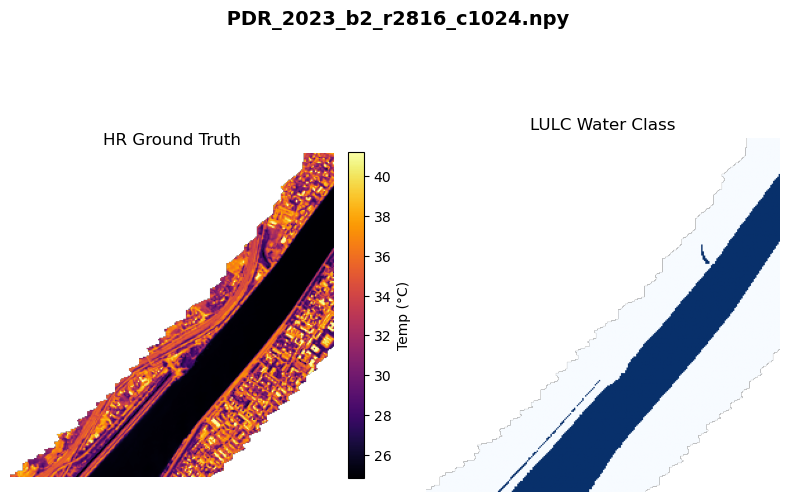

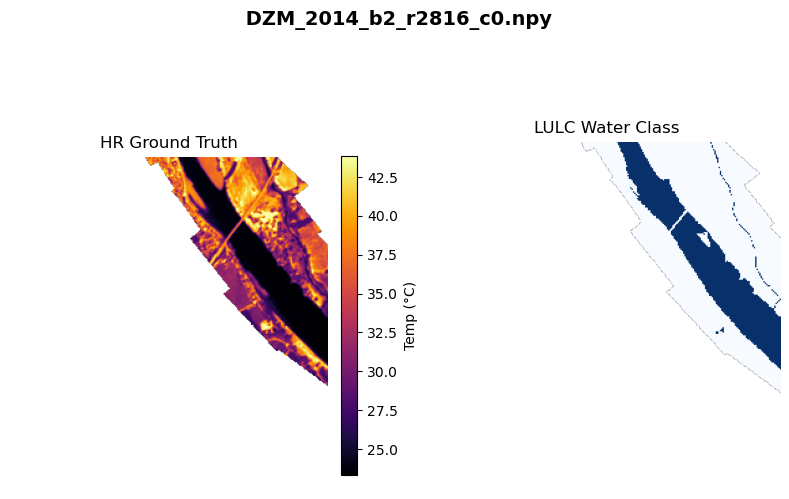

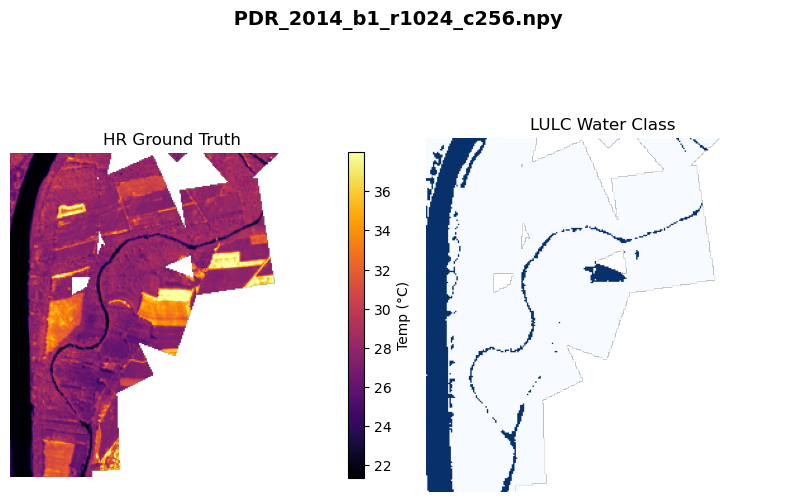

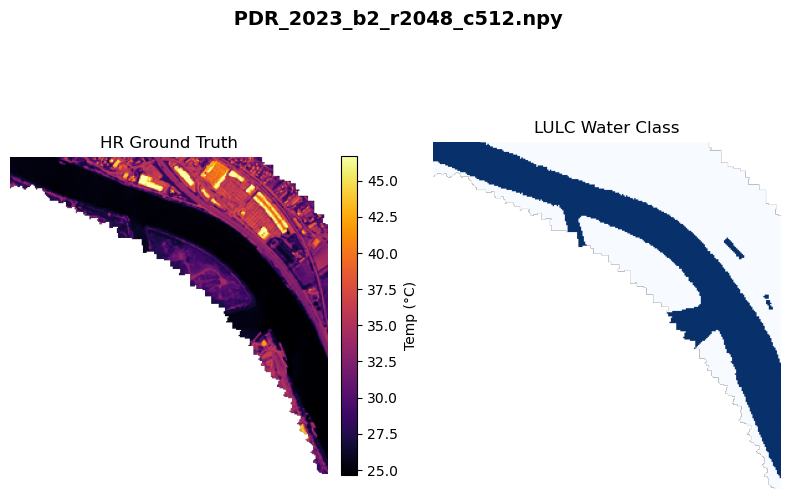

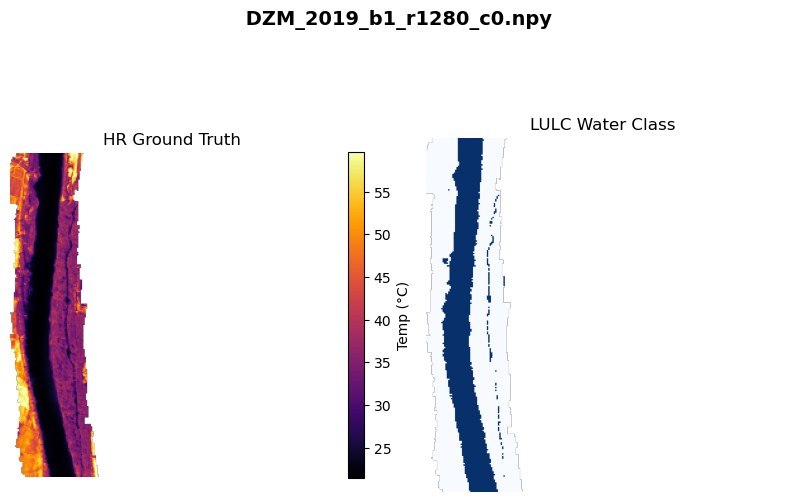

In [7]:
import numpy as np

# --- Step 1: Define the dedicated high-res SPADE folder ---
AUX_SPADE_HR_DIR = PATCHES_DIR / "val" / "AUX_SPADE_HR"

# --- Step 2: Diagnostic Loop for the 5 Validation Tiles ---
for sample in vis_samples:
    tile_name = sample['fname']  # e.g., 'BAS_2025_b2_r2560_c768'
    
    # Extract mask and compute valid bounds
    hr_mask = sample["hr_mask"].squeeze().numpy()
    valid = hr_mask > 0.5
    
    # 1. Denormalize and mask HR Ground Truth TIR
    hr_np = np.where(valid, sample["hr"][0].numpy() * HR_STD + HR_MEAN, np.nan)
    
    # 2. Manually load the exact matching HR SPADE array (.npy)
    # This directly pulls the true high-res layer you want to audit!
    spade_file_path = AUX_SPADE_HR_DIR / f"{tile_name}"
    
    if not spade_file_path.exists():
        print(f"Warning: Could not find {spade_file_path.name}, skipping.")
        continue
        
    spade_stack = np.load(spade_file_path)
    
    # 3. Extract the LULC slice from this specific HR stack
    # water
    lulc_hr = spade_stack[13, :, :] 
    lulc_masked = np.where(valid, lulc_hr, np.nan)
    
    # Compute robust physical temperature bounds
    valid_pixels = hr_np[np.isfinite(hr_np)]
    vmin = np.percentile(valid_pixels, 1) if len(valid_pixels) > 0 else 24.0
    vmax = np.percentile(valid_pixels, 99) if len(valid_pixels) > 0 else 28.0
    
    # --- Step 3: Plotting the Side-by-Side Audit ---
    fig, axes = plt.subplots(1, 2, figsize=(8, 6))
    fig.suptitle(f" {tile_name}", fontsize=14, fontweight='bold')
    
    # Panel 1: HR Target (Thermal reality)
    im0 = axes[0].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("HR Ground Truth")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Temp (°C)")
    
    # Panel 2: True High-Res LULC Array for SPADE
    im1 = axes[1].imshow(lulc_masked, cmap="Blues")
    axes[1].set_title("LULC Water Class")
    axes[1].axis("off")
    # plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Class ID")
    
    plt.tight_layout()
    plt.show()

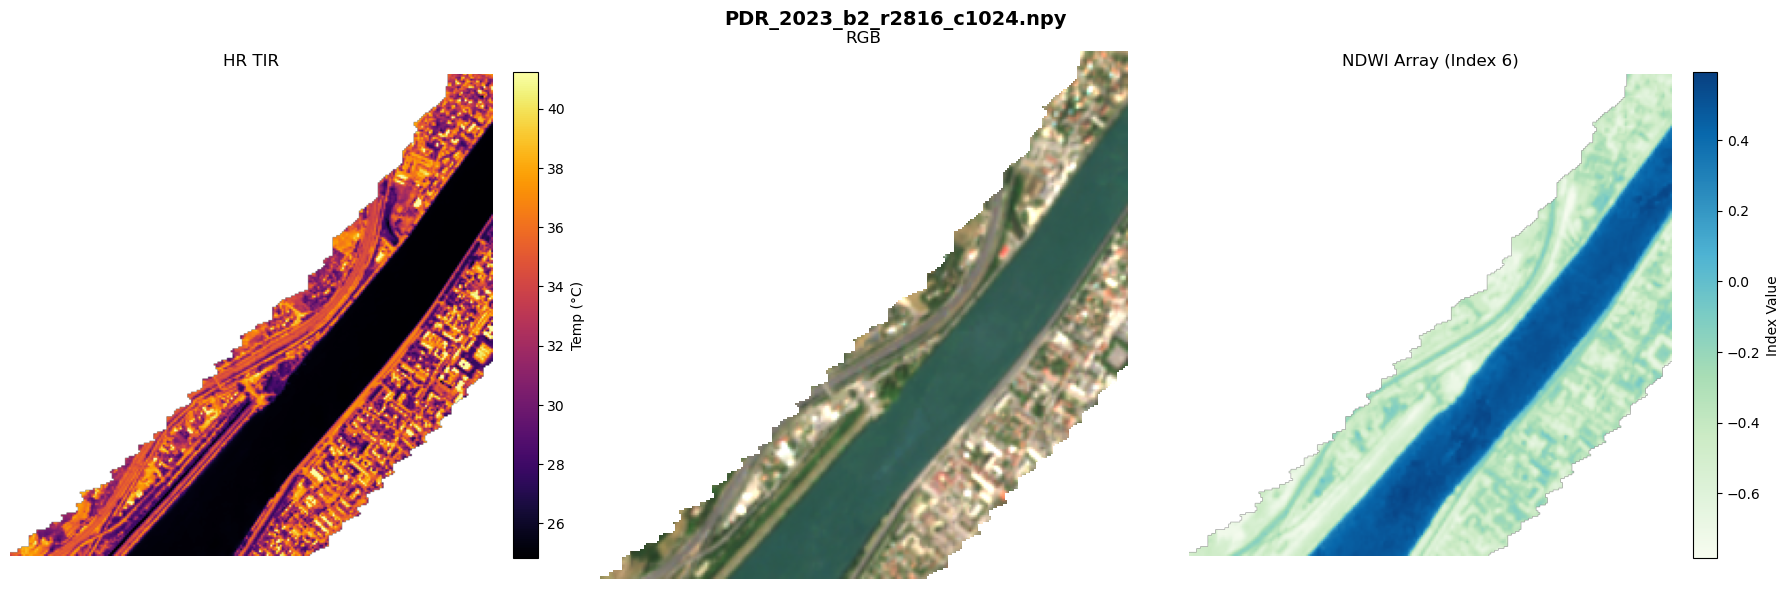

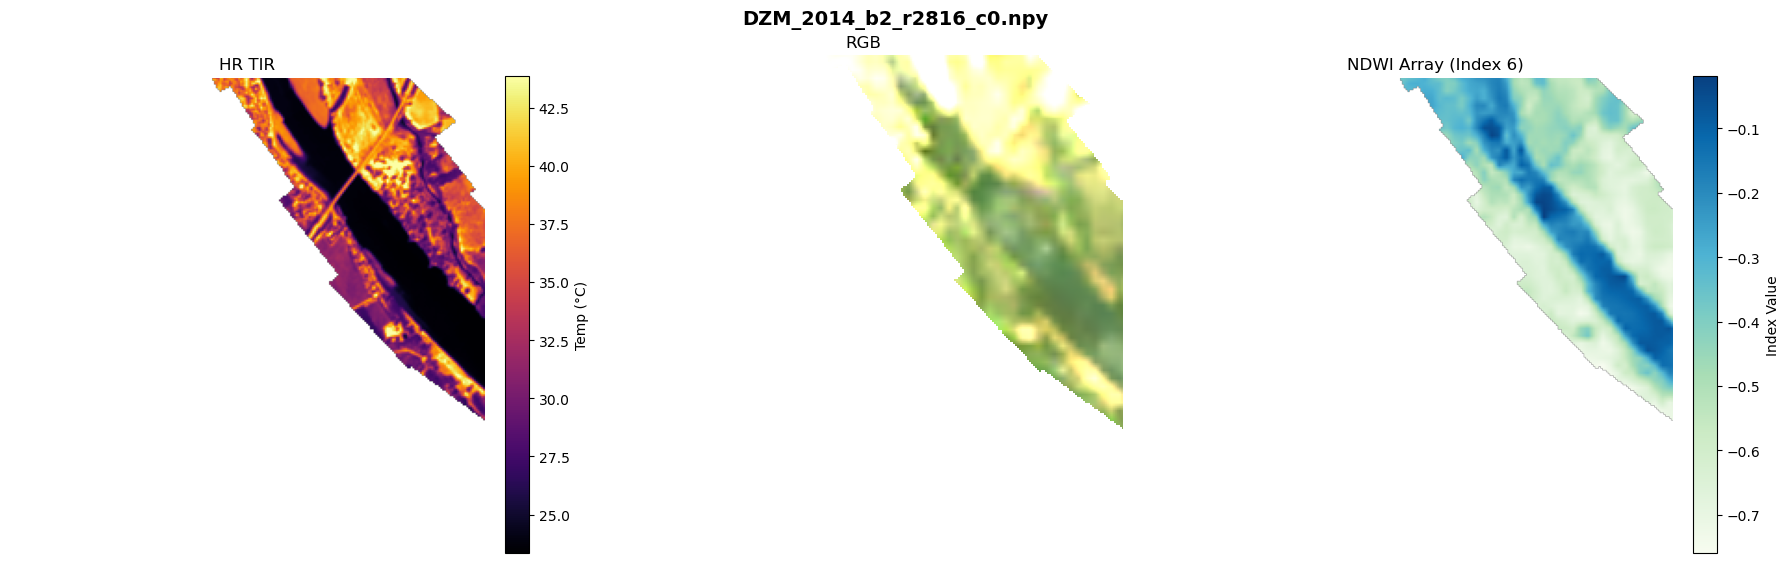

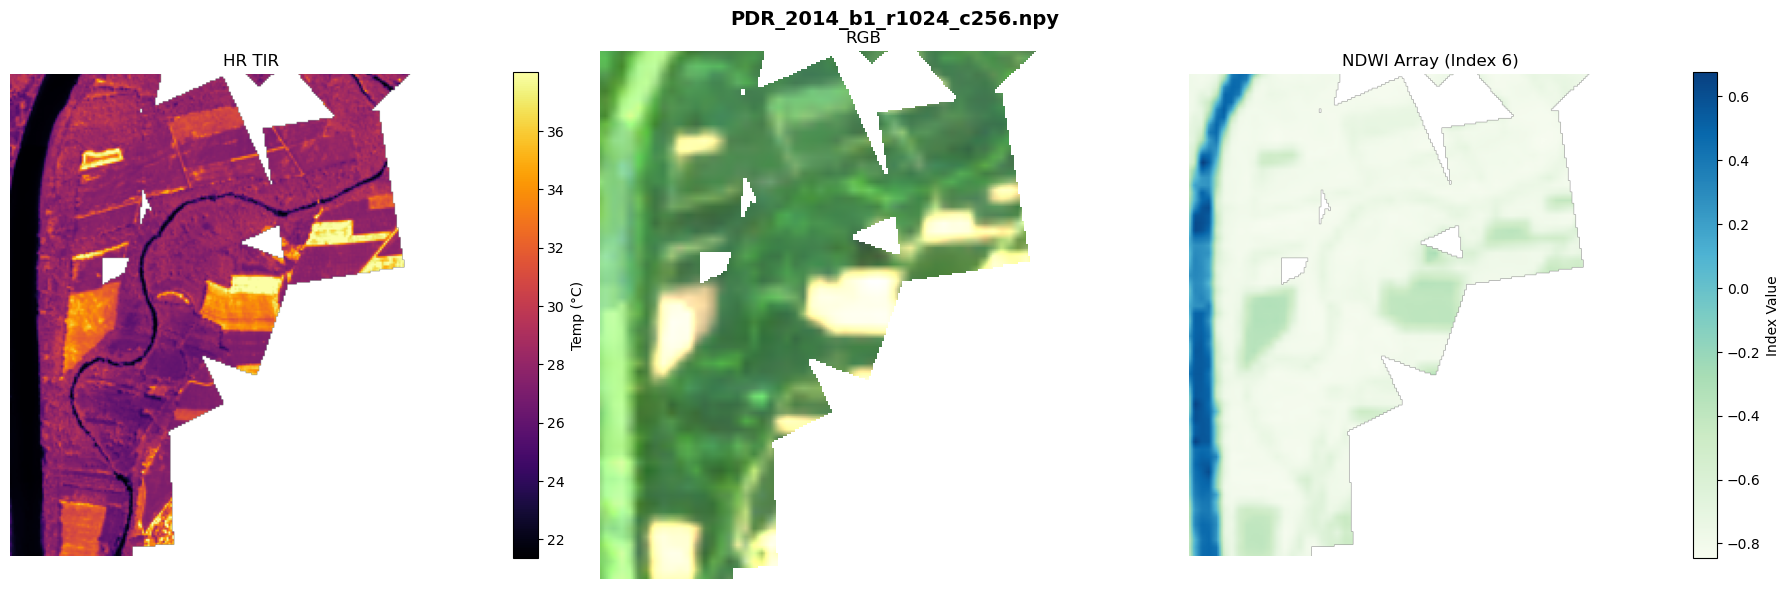

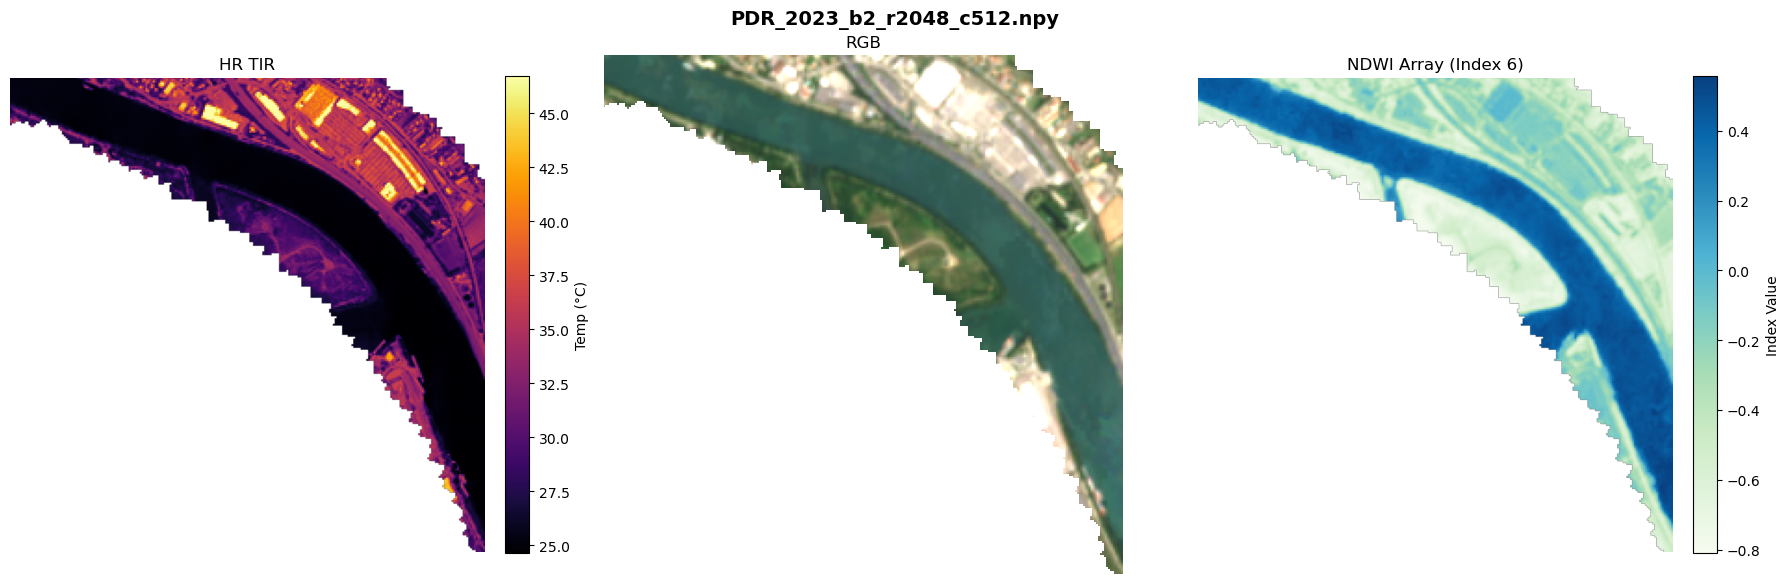

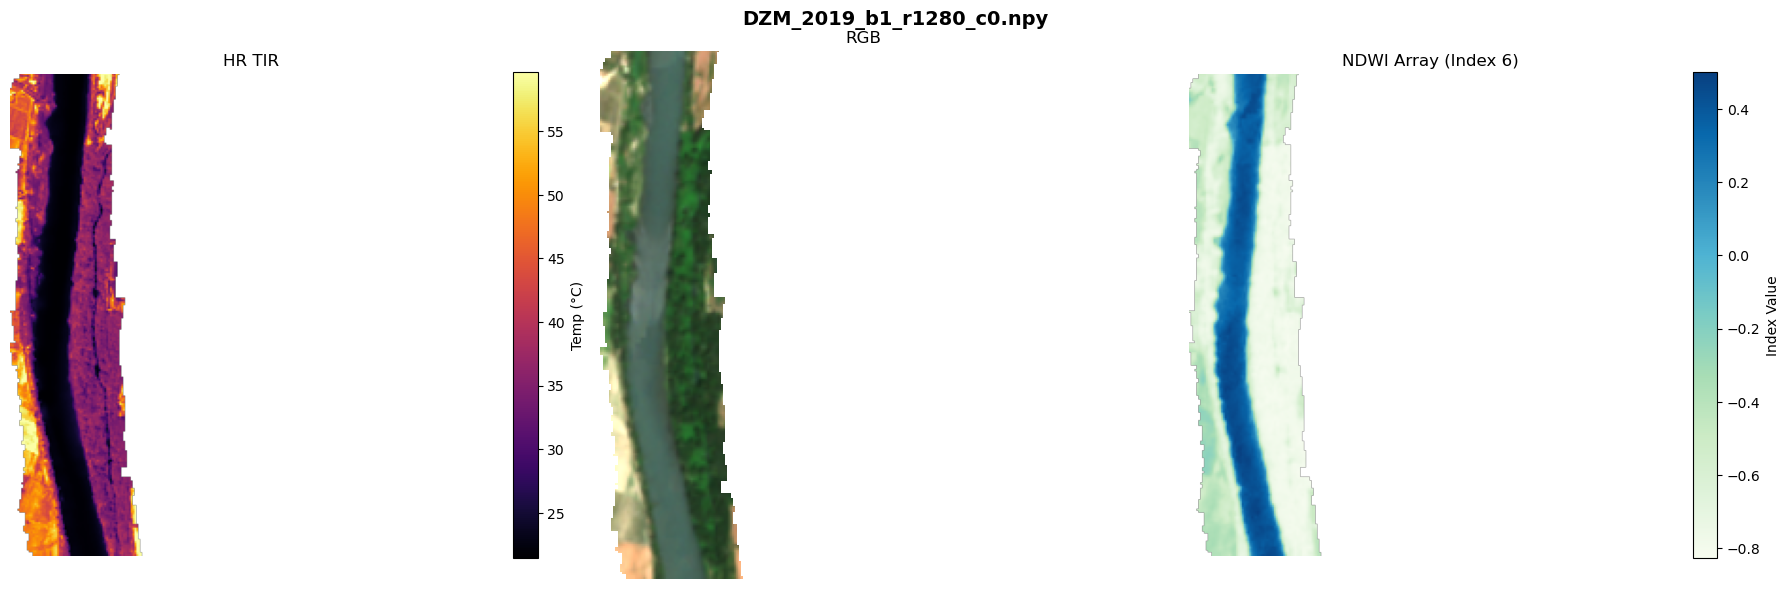

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Assuming PATCHES_DIR is defined in your interactive session
AUX_SPADE_HR_DIR = PATCHES_DIR / "val" / "AUX_SPADE_HR"

for sample in vis_samples:
    tile_name = sample['fname']
    
    hr_mask = sample["hr_mask"].squeeze().numpy()
    valid = hr_mask > 0.5
    
    # 1. Denormalize HR Ground Truth TIR
    hr_np = np.where(valid, sample["hr"][0].numpy() * HR_STD + HR_MEAN, np.nan)
    
    # 2. Load the SPADE array
    spade_file_path = AUX_SPADE_HR_DIR / f"{tile_name}"
    if not spade_file_path.exists():
        print(f"Warning: Could not find {spade_file_path.name}, skipping.")
        continue
        
    spade_stack = np.load(spade_file_path)
    
    # 3. Adaptive Sensor Selection for RGB Display
    # Check if the tile belongs to the 2013/2014 Landsat campaigns
    is_landsat = "2013" in tile_name or "2014" in tile_name
    
    if is_landsat:
        # Landsat mosaic routing based on your current local file indices
        # Let's pull your visible channels (Indices 2, 1, 0)
        rgb_img = spade_stack[[2, 1, 0], :, :]
        # Apply a stronger brightness boost factor for Landsat exposure tuning
        boost_factor = 12.0 
    else:
        # Standard Sentinel-2 routing (Indices 2, 1, 0)
        rgb_img = spade_stack[[2, 1, 0], :, :]
        boost_factor = 6.0

    rgb_img = np.transpose(rgb_img, (1, 2, 0))  # (C, H, W) -> (H, W, C)
    rgb_img = np.clip(rgb_img * boost_factor, 0, 1)            
    rgb_img[~valid] = np.nan
    
    # 4. Extract current NDWI (Index 6)
    ndwi_layer = spade_stack[6, :, :]
    ndwi_masked = np.where(valid, ndwi_layer, np.nan)
    
    # Robust temperature scaling limits
    valid_pixels = hr_np[np.isfinite(hr_np)]
    vmin = np.percentile(valid_pixels, 1) if len(valid_pixels) > 0 else 24.0
    vmax = np.percentile(valid_pixels, 99) if len(valid_pixels) > 0 else 28.0
    
    # --- Plotting Three-Panel Audit ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{tile_name}", fontsize=14, fontweight='bold')
    
    # Panel 1: Thermal Reality
    im0 = axes[0].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("HR TIR")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Temp (°C)")
    
    # Panel 2: True Color Imagery
    axes[1].imshow(rgb_img)
    axes[1].set_title(f"RGB")
    axes[1].axis("off")
    
    # Panel 3: NDWI Water Index Signature
    im2 = axes[2].imshow(ndwi_masked, cmap="GnBu")
    axes[2].set_title("NDWI Array (Index 6)")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="Index Value")
    
    plt.tight_layout()
    plt.show()

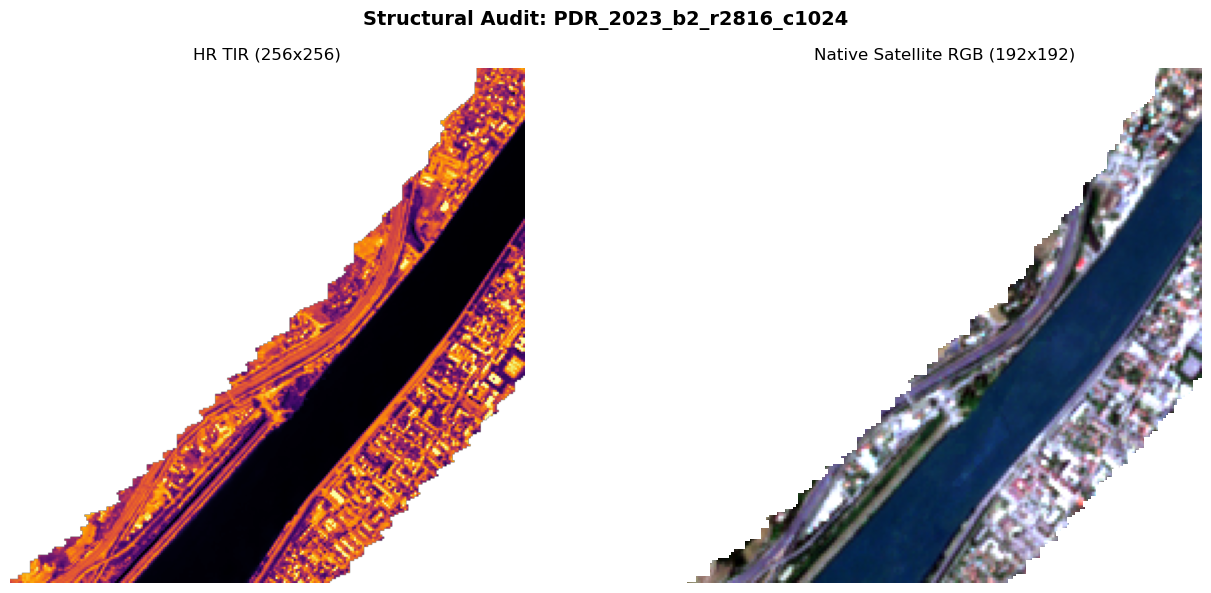

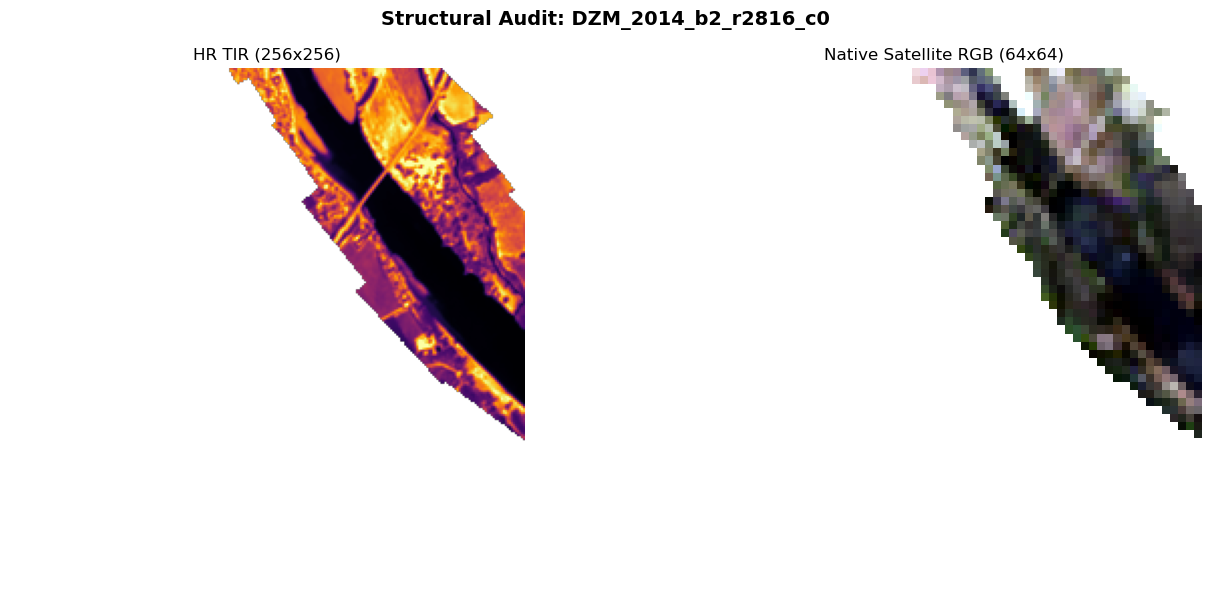

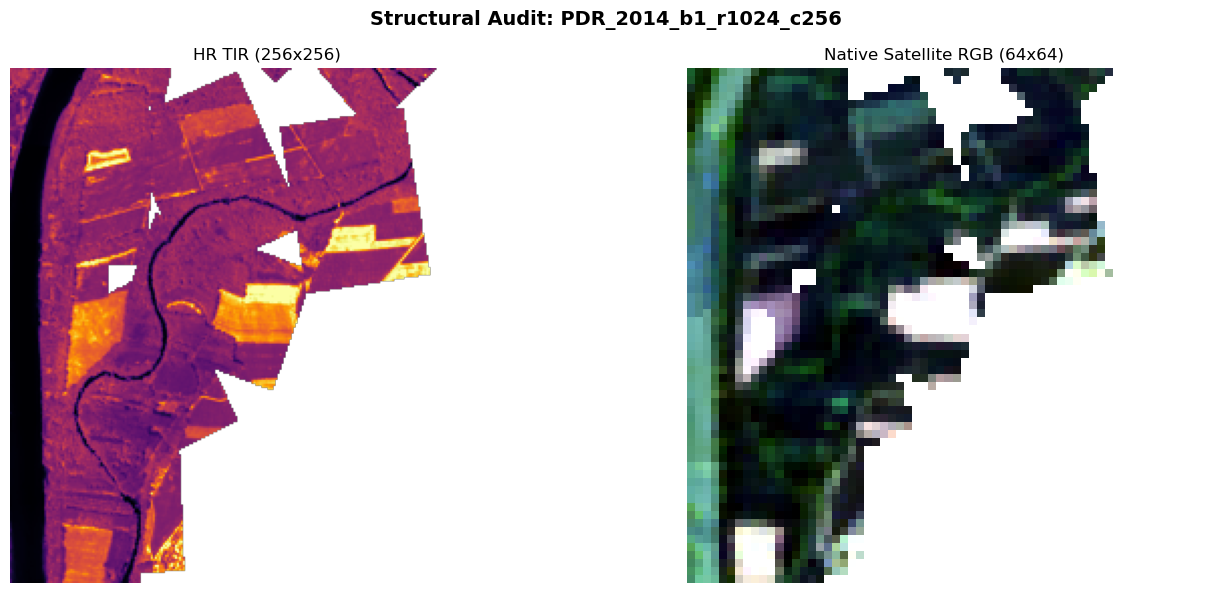

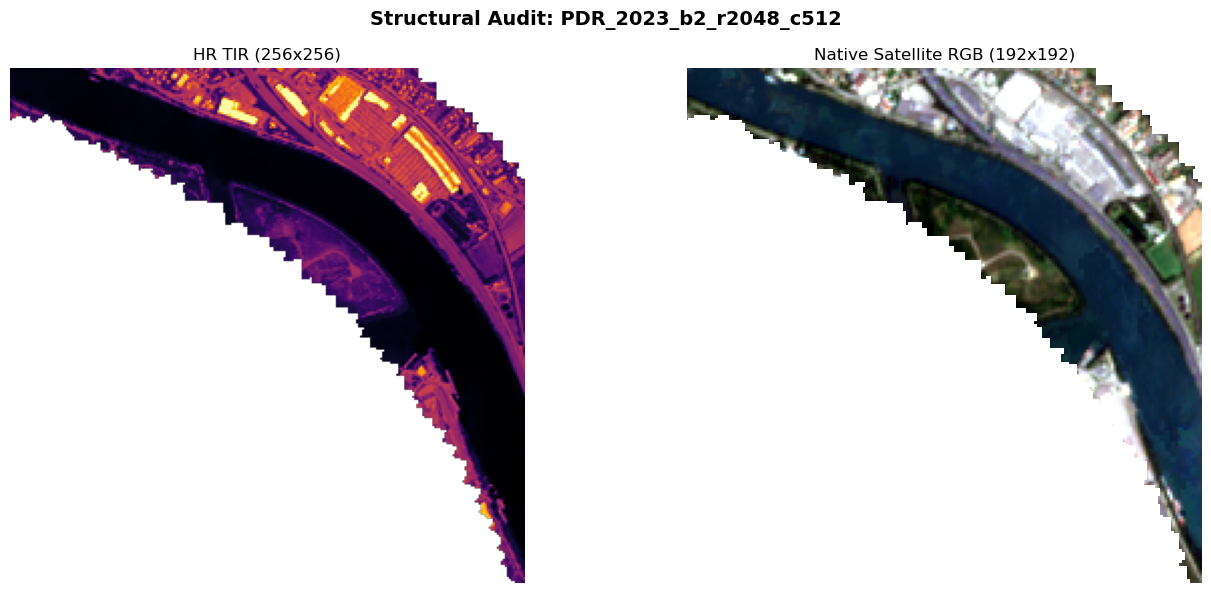

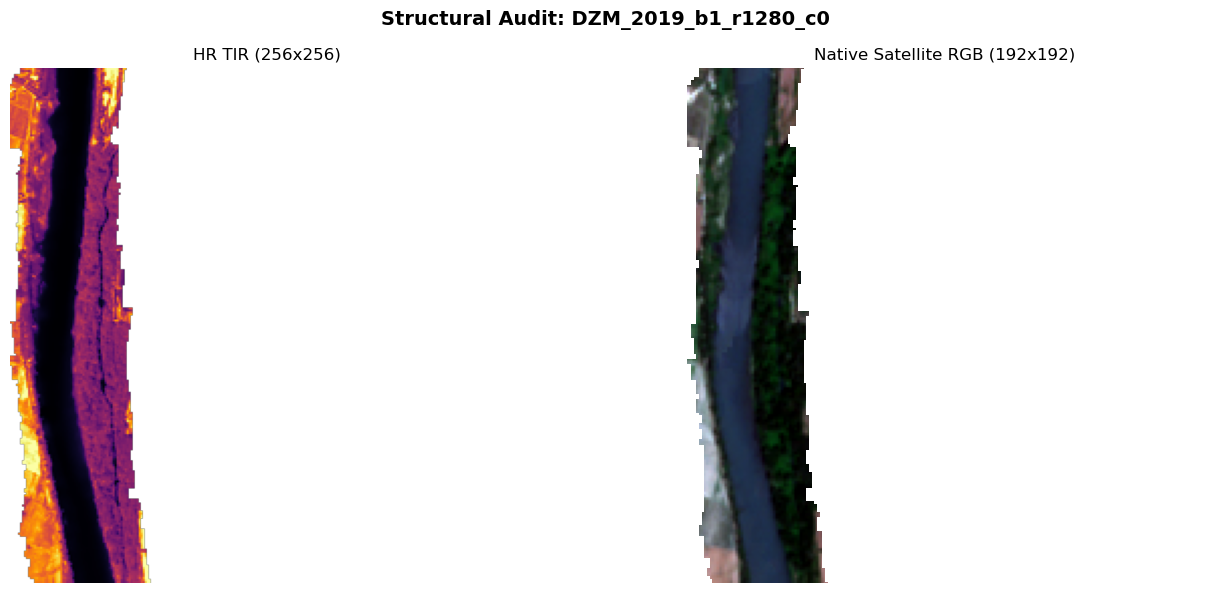

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds
from pathlib import Path
from cv2 import resize, INTER_NEAREST

# --- Configuration Paths ---
BASE_DIR = Path("/share/home/e2406751/Superresolution-TIR")
AUX_RAW_DIR = BASE_DIR / "data/AUX/auxiliary"
PATCHES_DIR = BASE_DIR / "data/processed/patches"
METADATA_PATH = PATCHES_DIR / "metadata.json"

# Load your metadata
with open(METADATA_PATH) as f:
    tile_metadata = json.load(f)

# Iterate through your samples
for idx, sample in enumerate(vis_samples):
    tile_name = sample['fname'] 
    tile_key = tile_name.replace(".npy", "")
    
    if tile_key not in tile_metadata:
        print(f"⚠️ Skipped {tile_name}: Missing in metadata.json")
        continue
        
    info = tile_metadata[tile_key]
    campaign = info["campaign"]
    bounds = info["bounds_2154"]
    raw_tif_path = AUX_RAW_DIR / f"{campaign}_aux.tif"
    
    if not raw_tif_path.exists():
        continue
        
    # 1. Extract Ground Truth Thermal Reality
    hr_mask = sample["hr_mask"].squeeze().numpy()
    valid_hr = hr_mask > 0.5
    hr_np = np.where(valid_hr, sample["hr"][0].numpy() * HR_STD + HR_MEAN, np.nan)
    
    # 2. Universal True-Color Mapping
    # Band 1=Blue, 2=Green, 3=Red (consistent across your downloads)
    with rasterio.open(raw_tif_path) as src:
        window = from_bounds(bounds["left"], bounds["bottom"], bounds["right"], bounds["top"], src.transform)
        
        raw_r = src.read(3, window=window, boundless=True, fill_value=0).astype(np.float32)
        raw_g = src.read(2, window=window, boundless=True, fill_value=0).astype(np.float32)
        raw_b = src.read(1, window=window, boundless=True, fill_value=0).astype(np.float32)

    rgb_raw = np.stack([raw_r, raw_g, raw_b], axis=-1)
    native_h, native_w, _ = rgb_raw.shape
    
    # 3. Robust 2%-95% Contrast Stretch
    rgb_stretched = np.zeros_like(rgb_raw)
    for i in range(3):
        band_slice = rgb_raw[:, :, i]
        valid_pixels = band_slice[band_slice > 0] if np.any(band_slice > 0) else band_slice
        p2, p95 = np.percentile(valid_pixels, 2), np.percentile(valid_pixels, 95)
        if p95 > p2:
            rgb_stretched[:, :, i] = np.clip((band_slice - p2) / (p95 - p2), 0, 1)
        else:
            rgb_stretched[:, :, i] = np.clip(band_slice - p2, 0, 1)

    # Apply mask for visuals
    valid_native = resize(valid_hr.astype(np.uint8), (native_w, native_h), interpolation=INTER_NEAREST) > 0
    rgb_stretched[~valid_native] = np.nan

    # 4. Display
    valid_pixels_tir = hr_np[np.isfinite(hr_np)]
    vmin = np.percentile(valid_pixels_tir, 1) if len(valid_pixels_tir) > 0 else 22.0
    vmax = np.percentile(valid_pixels_tir, 99) if len(valid_pixels_tir) > 0 else 38.0
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Structural Audit: {tile_key}", fontsize=14, fontweight='bold')
    
    axes[0].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("HR TIR (256x256)")
    axes[0].axis("off")
    
    axes[1].imshow(rgb_stretched)
    axes[1].set_title(f"Native Satellite RGB ({native_h}x{native_w})")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

In [10]:
# check center of patch
import numpy as np

patch = np.load("/share/home/e2406751/Superresolution-TIR/data/processed/patches/val/HR/DZM_2019_b1_r1280_c0.npy")

print(f"Patch shape: {patch.shape}")
print(f"Center pixel HR value: {patch[128, 128]:.2f} °C")

Patch shape: (256, 256)
Center pixel HR value: nan °C


In [29]:
from pyproj import Transformer

# -----------------------------
# Input bounds (EPSG:2154)
# -----------------------------
left = 831102.0
right = 833022.0
bottom = 6361741.4
top = 6363661.4

crs_in = "EPSG:2154"
crs_out = "EPSG:4326"

transformer = Transformer.from_crs(crs_in, crs_out, always_xy=True)

# -----------------------------
# Convert all 4 corners
# -----------------------------
lon_min, lat_min = transformer.transform(left, bottom)
lon_max, lat_max = transformer.transform(right, top)

# -----------------------------
# Output WGS84 bounding box
# -----------------------------
print("AOI bounds in WGS84 (EPSG:4326):")
print(f"lat_min: {lat_min:.6f}")
print(f"lat_max: {lat_max:.6f}")
print(f"lon_min: {lon_min:.6f}")
print(f"lon_max: {lon_max:.6f}")

# Optional: center
lat_center = (lat_min + lat_max) / 2
lon_center = (lon_min + lon_max) / 2

print("\nCenter point:")
print(f"Latitude:  {lat_center:.6f}")
print(f"Longitude: {lon_center:.6f}")

AOI bounds in WGS84 (EPSG:4326):
lat_min: 44.342415
lat_max: 44.359331
lon_min: 4.644559
lon_max: 4.669145

Center point:
Latitude:  44.350873
Longitude: 4.656852


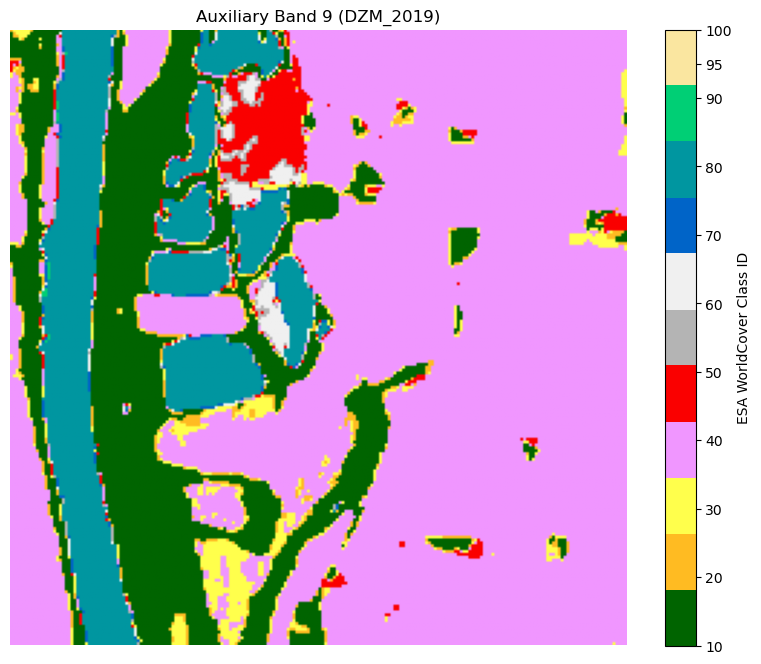

In [35]:
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Official ESA WorldCover mapping
ESA_COLORS = {
    10: "#006400", 20: "#ffbb22", 30: "#ffff4c", 40: "#f096ff", 
    50: "#fa0000", 60: "#b4b4b4", 70: "#f0f0f0", 80: "#0064c8", 
    90: "#0096a0", 95: "#00cf75", 100: "#fae6a0"
}

bounds = {
    "left": 831102.0,
    "right": 833022.0,
    "top": 6363661.4,
    "bottom": 6361741.4
}

def visualize_esa_band(aux_path, bnds, band_index=9):
    with rasterio.open(aux_path) as src:
        win = rasterio.windows.from_bounds(
            bnds["left"], bnds["bottom"], bnds["right"], bnds["top"], src.transform
        )
        data = src.read(band_index, window=win)
    
    plt.figure(figsize=(10, 8))
    
    # 1. Handle Categorical ESA Data
    if band_index == 9:
        # Create a colormap specifically for the values present in the data
        sorted_vals = sorted(ESA_COLORS.keys())
        colors = [ESA_COLORS[v] for v in sorted_vals]
        cmap = ListedColormap(colors)
        
        # Display: vmin/vmax set to cover the full ESA range (10-100)
        plt.imshow(data, cmap=cmap, vmin=10, vmax=100)
        plt.colorbar(label="ESA WorldCover Class ID", ticks=sorted_vals)
    
    # 2. Handle Continuous Spectral Data
    else:
        plt.imshow(data, cmap="viridis")
        plt.colorbar(label="Value")
        
    plt.title(f"Auxiliary Band {band_index} (DZM_2019)")
    plt.axis("off")
    plt.show()

# Update path to your full campaign auxiliary file
aux_path = "/share/home/e2406751/Superresolution-TIR/data/AUX/auxiliary/DZM_2019_aux.tif"
visualize_esa_band(aux_path, bounds, band_index=9)

In [11]:
import numpy as np
from pathlib import Path

# Load one test patch
patch_path = Path("/share/home/e2406751/Superresolution-TIR/data/processed/patches/train/AUX/PDR_2023_b1_r1792_c512.npy")
patch = np.load(patch_path)

print(f"Patch shape: {patch.shape}") # Should be (23, 64, 64)

# Channel mapping: 0-4: Spectral, 5: NDVI, 6: NDWI, 7: NDMI, 8-21: LC, 22: DEM
print(f"Spectral range: {patch[0,:,:].min():.2f} to {patch[0,:,:].max():.2f}") # Should be [0, 1]
print(f"Index (NDVI) range: {patch[5,:,:].min():.2f} to {patch[5,:,:].max():.2f}") # Should be [-1, 1]
print(f"DEM range: {patch[22,:,:].min():.2f} to {patch[22,:,:].max():.2f}") # Should be [0, 1]

# Check Landcover one-hot (sum along channel axis should be 1.0 per pixel)
lc_sum = patch[8:22, :, :].sum(axis=0)
print(f"LC mask sum (should be all 1s): {np.unique(lc_sum)}")

Patch shape: (23, 64, 64)
Spectral range: 0.03 to 0.40
Index (NDVI) range: -0.19 to 0.87
DEM range: 0.05 to 0.40
LC mask sum (should be all 1s): [1.]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load the specific patch
sample = test_ds[test_ds.files.index("BRC_2022_b0_r0_c0.npy")]

hr_np      = sample["hr"][0].numpy() * HR_STD + HR_MEAN
hr_mask    = sample["hr_mask"].squeeze().numpy()
water_mask = sample["water_mask"].squeeze().numpy()

# Mask invalid pixels
hr_np = np.where(hr_mask > 0.5, hr_np, np.nan)
valid_px = hr_np[np.isfinite(hr_np)]
vmin = np.percentile(valid_px, 1)
vmax = np.percentile(valid_px, 99)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle("BRC_2022_b0_r0_c0.npy — HR vs Water Mask", fontweight="bold")

im = axes[0].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title("HR Ground Truth")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046, label="Temp (°C)")

axes[1].imshow(water_mask, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title(f"Water Mask (sum={int(water_mask.sum())} px)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

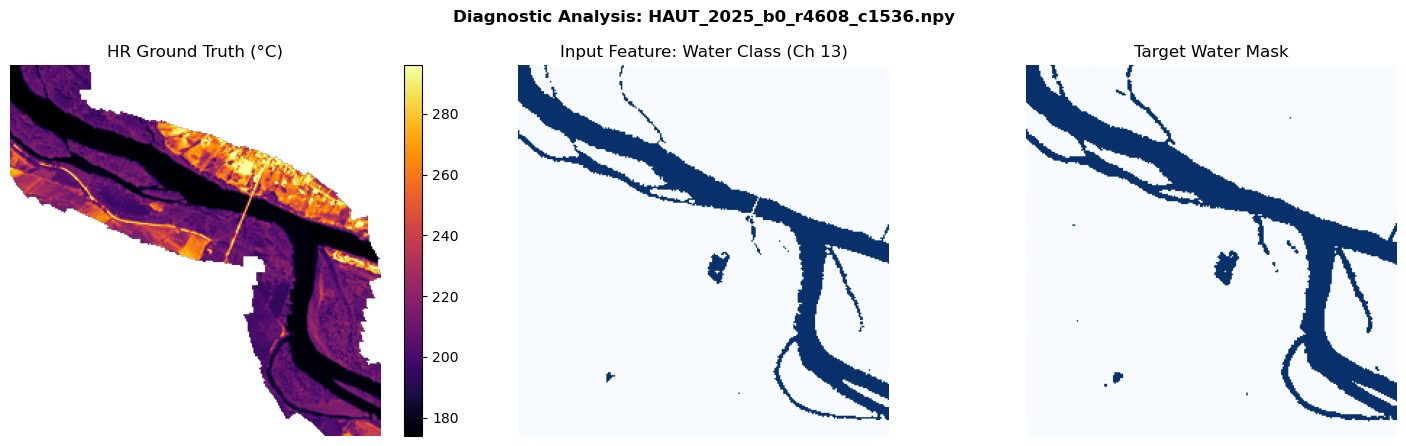

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
PATCHES_DIR = Path("/share/home/e2406751/Superresolution-TIR/data/processed/patches")
# fname = "HAUT_2025_b0_r4608_c1536.npy"
# fname = "PDR_2023_b2_r2304_c1024.npy"
# --- 1. Load Data ---
# Note: Ensure these paths match your actual directory structure
hr_path = PATCHES_DIR / "test" / "HR" / fname
aux_path = PATCHES_DIR / "test" / "AUX_SPADE_HR" / fname
wm_path = PATCHES_DIR / "test" / "WM" / fname # Based on your dataset.py, it's in a WM folder

hr = np.load(hr_path)
aux_hr = np.load(aux_path)
wm = np.load(wm_path)

# --- 2. Denormalization ---
# Using placeholders for HR_STD/MEAN as defined in your stats.json
# Ensure these match the values used in your training
hr_np = np.where(np.isfinite(hr), hr * HR_STD + HR_MEAN, np.nan)
valid = hr_np[np.isfinite(hr_np)]
vmin, vmax = np.percentile(valid, 1), np.percentile(valid, 99)

# --- 3. Extract Water Channel ---
# Based on your map: COSIA starts at index 8. Class 6 (Water) is index 5 in that block.
# Channel = 8 + 5 = 13
water_class_channel = aux_hr[13, :, :]

# --- 4. Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f"Diagnostic Analysis: {fname}", fontweight="bold")

# Plot 1: Ground Truth
im0 = axes[0].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title("HR Ground Truth (°C)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Plot 2: COSIA Water Class (Input Feature)
im1 = axes[1].imshow(water_class_channel, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Input Feature: Water Class (Ch 13)")
axes[1].axis("off")

# Plot 3: Target Water Mask
axes[2].imshow(wm.squeeze(), cmap="Blues", vmin=0, vmax=1)
axes[2].set_title(f"Target Water Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Data distribution shift of tests vs train

In [1]:
import os
import numpy as np
import rasterio

# --- Function to Extract Pixels from Campaigns ---
def extract_pixels(data_dir, campaigns, output_filename):
    total_pixels = []
    water_pixels = []
    
    for p in campaigns:
        path = os.path.join(data_dir, "HR_downsampled", f"{p}.tif")
        # Direct folder matching your setup
        aux_path = os.path.join(data_dir, "AUX", "water_masks", f"{p}_water_mask.tif") 
        
        if os.path.exists(path) and os.path.exists(aux_path):
            print(f"[Processing] {p}...")
            with rasterio.open(path) as src:
                img = src.read(1).astype(float)
                # Base mask to drop NaNs and padding zeros
                valid_base = (np.isfinite(img) & (img != src.nodata))  

            with rasterio.open(aux_path) as src_aux:
                mask_img = src_aux.read(1)
                
            # Total pixels (Land + Water inside valid flight swath)
            total_pixels.extend(img[valid_base].flatten())
            
            # Water-only pixels (Where base is valid AND mask indicates water)
            # Adjust '== 1' if your water mask uses a different class integer
            water_mask = valid_base & (mask_img == 1)
            water_pixels.extend(img[water_mask].flatten())
            
    # Save arrays as a single compressed file
    np.savez_compressed(output_filename, total=np.array(total_pixels), water=np.array(water_pixels))
    print(f"Saved arrays to cache file: {output_filename}")

# --- Configurations ---
DATA_DIR = "/share/home/e2406751/Superresolution-TIR/data"
TRAIN = ["BAS_2025", "DZM_2013", "DZM_2014", "DZM_2019", "DZM_2023", "PDR_2013", "PDR_2014", "PDR_2023"]
TEST = ["BRC_2022", "BRC_2023", "HAUT_2025"]

# Run the extraction once
print("Extracting Train/Val...")
extract_pixels(DATA_DIR, TRAIN, "train_pixels.npz")

print("\nExtracting Test...")
extract_pixels(DATA_DIR, TEST, "test_pixels.npz")

Extracting Train/Val...
[Processing] BAS_2025...
[Processing] DZM_2013...
[Processing] DZM_2014...
[Processing] DZM_2019...
[Processing] DZM_2023...
[Processing] PDR_2013...
[Processing] PDR_2014...
[Processing] PDR_2023...
Saved arrays to cache file: train_pixels.npz

Extracting Test...
[Processing] BRC_2022...
[Processing] BRC_2023...
[Processing] HAUT_2025...
Saved arrays to cache file: test_pixels.npz


In [2]:
import os
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

## Load cached arrays 
train_cache = np.load("/share/home/e2406751/Superresolution-TIR/data/train_pixels.npz")
test_cache = np.load("/share/home/e2406751/Superresolution-TIR/data/test_pixels.npz")

train_total, train_water = train_cache['total'], train_cache['water']
test_total, test_water = test_cache['total'], test_cache['water']

In [18]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Load cached arrays
train_data = np.load("/share/home/e2406751/Superresolution-TIR/data/train_pixels.npz")
test_data  = np.load("/share/home/e2406751/Superresolution-TIR/data/test_pixels.npz")

def run_tests(train, test, label):
    print(f"\n ---- {label} ------ ")
    print(f"  Train — n={len(train):,}, mean={train.mean():.2f}°C, "
          f"std={train.std():.2f}°C, median={np.median(train):.2f}°C")
    print(f"  Test  — n={len(test):,},  mean={test.mean():.2f}°C, "
          f"std={test.std():.2f}°C, median={np.median(test):.2f}°C")
    
    def interpret(p):
        if p < 0.05:
            return "p < 0.05"
        else:
            return f"p = {p:.3e}"
        
    # Welch t-test — does not assume equal variance
    t_test= stats.ttest_ind(train, test, equal_var=False, alternative='two-sided')
    print(f"\nWelch T-test:  t={t_test.statistic:.4f}, {interpret(t_test.pvalue)}")
    print("T-test: ", t_test)
 
    ks_test = stats.ks_2samp(train, test, alternative='two-sided')
    print(f"\n  KS test: D={ks_test.statistic:.4f}, {interpret(ks_test.pvalue)}")
    print("KS test: ", ks_test)

    return t_test.statistic, t_test.pvalue, ks_test.statistic, ks_test.pvalue

# Run both
run_tests(train_data["total"], test_data["total"], "All Valid Pixels")
run_tests(train_data["water"], test_data["water"], "Water Pixels Only")


 ---- All Valid Pixels ------ 
  Train — n=3,751,190, mean=30.56°C, std=6.25°C, median=28.86°C
  Test  — n=1,407,163,  mean=29.25°C, std=5.92°C, median=28.92°C

Welch T-test:  t=220.6920, p < 0.05
T-test:  TtestResult(statistic=220.69202929877494, pvalue=0.0, df=2653968.421823688)

  KS test: D=0.1992, p < 0.05
KS test:  KstestResult(statistic=0.1991996562916495, pvalue=0.0, statistic_location=24.79605484008789, statistic_sign=-1)

 ---- Water Pixels Only ------ 
  Train — n=1,227,086, mean=25.39°C, std=2.93°C, median=25.07°C
  Test  — n=448,653,  mean=25.00°C, std=2.98°C, median=24.39°C

Welch T-test:  t=74.1305, p < 0.05
T-test:  TtestResult(statistic=74.1305215856395, pvalue=0.0, df=787323.604831239)

  KS test: D=0.2786, p < 0.05
KS test:  KstestResult(statistic=0.2786435831735567, pvalue=0.0, statistic_location=24.63178253173828, statistic_sign=-1)


(74.1305215856395, 0.0, 0.2786435831735567, 0.0)

Total Landscape: We see a massive mean environment divergence ($t = 220.69$) and a clear structural distribution shift ($D = 0.199, p \approx 0$). This mathematically confirms that the overall background thermal context shifts radically between splits due to the low-vs-high elevation topography.

Water Channel Only: The mean divergence drops drastically ($t = 74.13$), showing the water channels track much closer together in absolute temperature. However, the KS test ($D = 0.278$) catches a structural shape mismatch peaking right at $24.6^\circ\text{C}$, indicating that the high-elevation test catchment compresses or skews the water temperature distribution compared to the lowland training baseline."

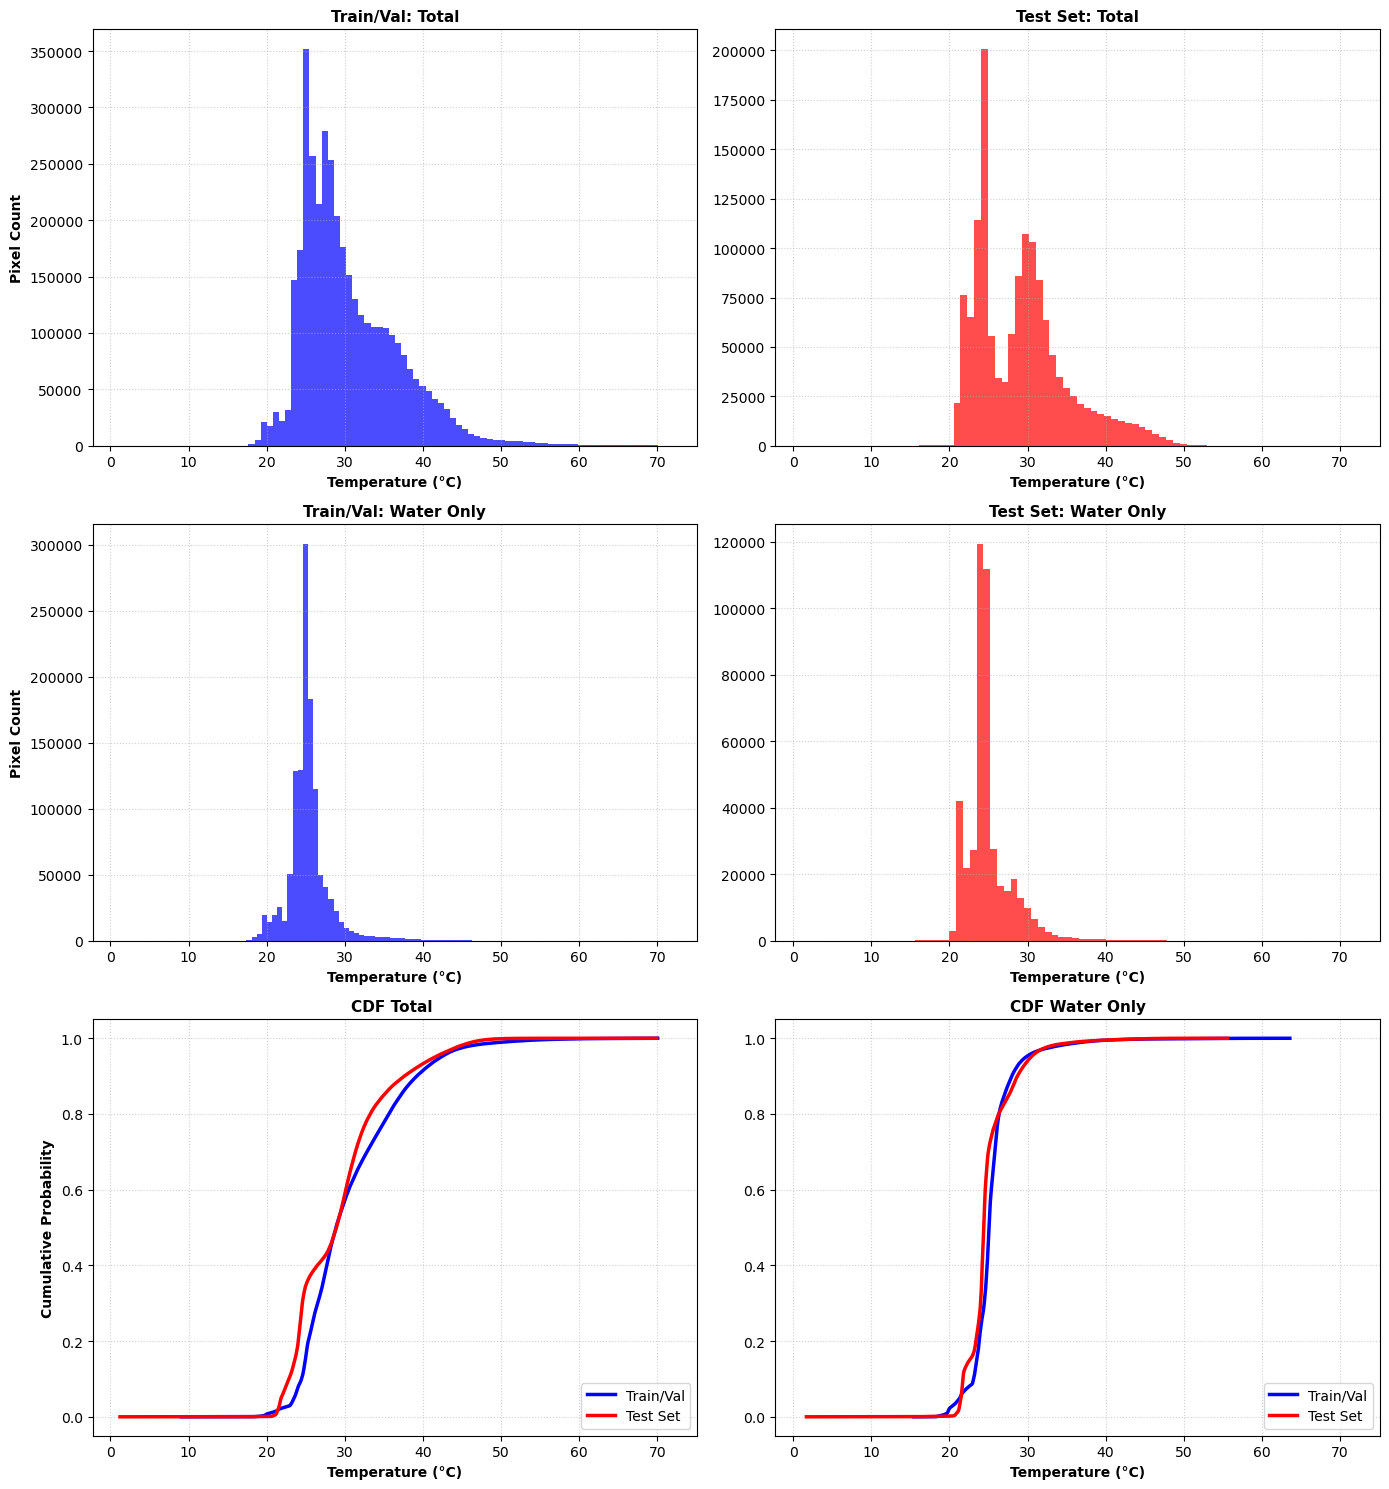

In [7]:
# trimming outliers for better visualization
def trim_outliers(data):
    low = np.percentile(data, 0.5)
    high = np.percentile(data, 99.5)
    return data[(data >= low) & (data <= high)], low, high

train_total_trimmed, tr_tot_l, tr_tot_h = trim_outliers(train_total)
test_total_trimmed, te_tot_l, te_tot_h = trim_outliers(test_total)
train_water_trimmed, tr_wat_l, tr_wat_h = trim_outliers(train_water)
test_water_trimmed, te_wat_l, te_wat_h = trim_outliers(test_water)

# Shared axis ranges across train/test columns
tot_xlim = (min(tr_tot_l, te_tot_l) - 1, max(tr_tot_h, te_tot_h) + 1)
wat_xlim = (min(tr_wat_l, te_wat_l) - 1, max(tr_wat_h, te_wat_h) + 1)

# plotting
# fig, axes = plt.subplots(3, 2, figsize=(14, 14))
# This automatically forces every row and column to share the exact same x-axis bounds
fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True)

#  Histograms Only (Total Landscape)
axes[0, 0].hist(train_total, bins=80, color='blue', alpha=0.7)
axes[0, 0].set_title("Train/Val: Total", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Pixel Count", fontweight='bold')
# axes[0, 0].set_xlim(tot_xlim)

axes[0, 1].hist(test_total, bins=80, color='red', alpha=0.7)
axes[0, 1].set_title("Test Set: Total", fontsize=11, fontweight='bold')
# axes[0, 1].set_xlim(tot_xlim)

# Histograms Only (Water Channel Only)
axes[1, 0].hist(train_water, bins=80, color='blue', alpha=0.7)
axes[1, 0].set_title("Train/Val: Water Only", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("Pixel Count", fontweight='bold')
# axes[1, 0].set_xlim(wat_xlim)

axes[1, 1].hist(test_water, bins=80, color='red', alpha=0.7)
axes[1, 1].set_title("Test Set: Water Only", fontsize=11, fontweight='bold')
# axes[1, 1].set_xlim(wat_xlim)

# CDF Line Overlay Plots
def plot_cdf_line(ax, data, color, label):
    sorted_data = np.sort(data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    # Stride calculation for lighter memory usage when drawing lines
    if len(sorted_data) > 10000:
        stride = len(sorted_data) // 10000
        sorted_data, y_vals = sorted_data[::stride], y_vals[::stride]
    ax.plot(sorted_data, y_vals, color=color, linewidth=2.5, label=label)

# CDF Left Panel: Total Landscape Overlay
plot_cdf_line(axes[2, 0], train_total, color='blue', label='Train/Val')
plot_cdf_line(axes[2, 0], test_total, color='red', label='Test Set')
axes[2, 0].set_title("CDF Total ", fontsize=11, fontweight='bold')
axes[2, 0].set_xlabel("Temperature (°C)", fontweight='bold')
axes[2, 0].set_ylabel("Cumulative Probability", fontweight='bold')
# axes[2, 0].set_xlim(tot_xlim)
axes[2, 0].legend(loc='lower right')

# CDF Right Panel: Water Channel Overlay
plot_cdf_line(axes[2, 1], train_water, color='blue', label='Train/Val')
plot_cdf_line(axes[2, 1], test_water, color='red', label='Test Set')
axes[2, 1].set_title("CDF Water Only", fontsize=11, fontweight='bold')
axes[2, 1].set_xlabel("Temperature (°C)", fontweight='bold')
# axes[2, 1].set_xlim(wat_xlim)
axes[2, 1].legend(loc='lower right')

# Apply grid layout to all panels simultaneously
for ax in axes.flatten():
    ax.tick_params(labelbottom=True)
    ax.set_xlabel("Temperature (°C)", fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

[INFO] Gathering DEM elevation profiles from the last AUX band...
[WARNING] File not found: /share/home/e2406751/Superresolution-TIR/data/AUX/auxiliary/BRC_2024_aux.tif


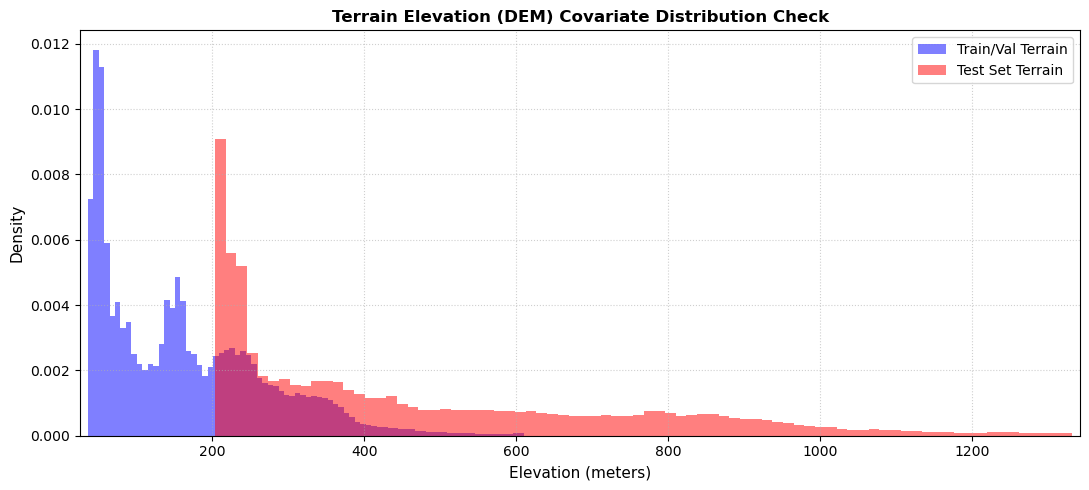

In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

def extract_dem_distributions(data_dir, split_prefixes):
    elevation_list = []
    
    for prefix in split_prefixes:
        # Using the exact auxiliary subdirectory path structure from your setup
        aux_path = os.path.join(data_dir, "AUX", "auxiliary", f"{prefix}_aux.tif") 
        
        if not os.path.exists(aux_path):
            print(f"[WARNING] File not found: {aux_path}")
            continue
            
        with rasterio.open(aux_path) as src_aux:
            # Dynamically target the last band (DEM)
            dem_band_idx = src_aux.count
            dem_img = src_aux.read(dem_band_idx).astype(float)
            aux_nodata = src_aux.nodatavals[dem_band_idx - 1]
            
            # Read band 1 (water mask) to isolate the valid flight swath boundaries
            mask_band = src_aux.read(1)
            
        # Filter the DEM array using its own native grid dimensions
        if aux_nodata is not None:
            is_valid_terrain = (dem_img != aux_nodata) & (~np.isnan(dem_img))
        else:
            is_valid_terrain = (dem_img != 0) & (~np.isnan(dem_img))
            
        # Ensure we stay within the actual flight mapping boundaries
        is_inside_swath = (mask_band >= 0) 
        final_valid_mask = is_valid_terrain & is_inside_swath
        
        # Safely extract elevations 
        valid_elevations = dem_img[final_valid_mask]
        elevation_list.extend(valid_elevations.flatten())
        
    return np.array(elevation_list)

# --- Path Configuration ---
DATA_DIR = "/share/home/e2406751/Superresolution-TIR/data" 
TRAIN_CAMPAIGNS = ["BAS_2025", "DZM_2013", "DZM_2014", "DZM_2019", "DZM_2023", "PDR_2013", "PDR_2014", "PDR_2023"] 
TEST_CAMPAIGNS = ["BRC_2022", "BRC_2023", "HAUT_2025"]

print("[INFO] Gathering DEM elevation profiles from the last AUX band...")
train_dem = extract_dem_distributions(DATA_DIR, TRAIN_CAMPAIGNS)
test_dem = extract_dem_distributions(DATA_DIR, TEST_CAMPAIGNS)

# --- Apply Two-Sided Cap to Ignore Outliers/Background Padding ---
def trim_terrain(data):
    if len(data) == 0:
        return data, 0, 100
    low = np.percentile(data, 0.5)
    high = np.percentile(data, 99.5)
    return data[(data >= low) & (data <= high)], low, high

train_dem_trimmed, tr_low, tr_high = trim_terrain(train_dem)
test_dem_trimmed, te_low, te_high = trim_terrain(test_dem)

# --- Plot the Terrain Covariate Comparison ---
plt.figure(figsize=(11, 5))

# Plotting as Density Histograms so the scales match even if pixel counts differ
if len(train_dem_trimmed) > 0:
    plt.hist(train_dem_trimmed, bins=80, color='blue', alpha=0.5, density=True, label='Train/Val Terrain')
if len(test_dem_trimmed) > 0:
    plt.hist(test_dem_trimmed, bins=80, color='red', alpha=0.5, density=True, label='Test Set Terrain')

plt.title("Terrain Elevation (DEM) Covariate Distribution Check", fontsize=12, fontweight='bold')
plt.xlabel("Elevation (meters)", fontsize=11)
plt.ylabel("Density", fontsize=11)

# Set horizontal limits safely around data bounds
x_min = min(tr_low, te_low) - 10
x_max = max(tr_high, te_high) + 10
plt.xlim(x_min, x_max)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Inference per campaign

In [4]:
from scripts.evaluation.inference import run_inference_pipeline

df = run_inference_pipeline(
    model=model,
    splits=["test"],
    patches_dir=BASE / "data/processed/patches",
    metadata_path=BASE / "data/processed/patches/metadata.json",
    stats_path=BASE / "data/processed/patches/stats.json",
    output_csv=BASE / "results/per_patch_metrics.csv",
    output_npz=BASE / "results/inference_raw.npz",
    ) 


── Processing Split: test ──


test:   6%|▋         | 4/64 [00:00<00:04, 14.51it/s]

test: 100%|██████████| 64/64 [00:03<00:00, 16.08it/s]



Saved metadata registry → /share/home/e2406751/Superresolution-TIR/results/per_patch_metrics.csv
Saved complete inference tensors → /share/home/e2406751/Superresolution-TIR/results/inference_raw.npz


In [5]:
import numpy as np
import pandas as pd

df = pd.read_csv(BASE / "results/per_patch_metrics.csv")
data = np.load(BASE / "results/inference_raw.npz", allow_pickle=True) 

sr = data["sr"]
hr = data["hr"]
lr = data["lr"]
hr_mask = data["hr_mask"]
water_mask = data["water_mask"]
row = data["row"]
col = data["col"]
campaigns = data["campaign"]
patch_ids = data["patch_id"]

In [10]:
# Convert masks to clean boolean arrays
hr_mask = data["hr_mask"] > 0.5
water_mask = data["water_mask"] > 0.5

# Isolate land and pure water regions
land_mask = hr_mask & (~water_mask)
pure_water_mask = hr_mask & water_mask

In [6]:
import json
from types import SimpleNamespace

# 1. Load stats
STATS_PATH = BASE / "data/processed/patches/stats.json"
with open(STATS_PATH) as f:
    stats_data = json.load(f)

# 2. Create an empty container that allows dot notation on the fly
module = SimpleNamespace()

# 3. Assign your training properties directly
module.DATA_RANGE = stats_data["hr_data_range"]
module.DATA_MIN   = stats_data["hr_percentiles"]["p1"]

print(f"Container ready: module.DATA_MIN = {module.DATA_MIN}")

Container ready: module.DATA_MIN = 20.763620376586914


In [7]:
import torch
from scripts.utils.metrics import compute_metrics

# Use GPU if available to speed up LPIPS, otherwise CPU works fine
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reshape arrays to 4D Tensors (B, C, H, W) as expected by the metric code
# .unsqueeze(1) adds the required channel dimension
sr_tensor = torch.from_numpy(sr).unsqueeze(1).to(device)
hr_tensor = torch.from_numpy(hr).unsqueeze(1).to(device)
hr_mask_tensor = torch.from_numpy(data["hr_mask"]).unsqueeze(1).to(device).float()
water_mask_tensor = torch.from_numpy(data["water_mask"]).unsqueeze(1).to(device).float()


patch_metrics_list = []

print("Computing structural and perceptual metrics patch-by-patch...")
for i in range(len(patch_ids)):
    with torch.no_grad():
        m_dict = compute_metrics(
            module=module,
            sr=sr_tensor[i:i+1],
            hr=hr_tensor[i:i+1],
            hr_mask=hr_mask_tensor[i:i+1],
            stage="test",
            water_mask=water_mask_tensor[i:i+1]
        )
    
    # Store patch identifier metadata
    row_metrics = {
        "patch_id": patch_ids[i],
        "campaign": campaigns[i]
    }
    
    # Extract structural scores out of PyTorch tensors safely
    for k, v in m_dict.items():
        row_metrics[k] = v.item() if (v is not None and torch.is_tensor(v)) else np.nan
        
    patch_metrics_list.append(row_metrics)

df_all_metrics = pd.DataFrame(patch_metrics_list)

Computing structural and perceptual metrics patch-by-patch...


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_

In [8]:
def aggregate_metrics(df_group):
    return pd.Series({
        "Water_MAE":  df_group["water_mae"].mean(),
        "Water_RMSE": df_group["water_rmse"].mean(),
        "Water_PSNR": df_group["water_psnr"].mean(),
        "Water_SSIM": df_group["water_ssim"].mean(),
        "Water_LPIPS":df_group["water_lpips"].mean(),
        
        "Land_MAE":   df_group["land_mae"].mean(),
        "Land_RMSE":  df_group["land_rmse"].mean(),
        "Land_PSNR":  df_group["land_psnr"].mean(),
        "Land_SSIM":  df_group["land_ssim"].mean(),
        "Land_LPIPS": df_group["land_lpips"].mean(),
    })

# Campaign Summaries
df_campaign_summary = df_all_metrics.groupby("campaign", as_index=False).apply(aggregate_metrics)
print("\n=== PERFORMANCE SUMMARY PER CAMPAIGN ===")
print(df_campaign_summary.to_markdown(index=False))

# Total Combined Test Set Summary
df_total_summary = aggregate_metrics(df_all_metrics).to_frame().T
df_total_summary.insert(0, "campaign", "TOTAL TEST SET")
print("\n=== GLOBAL TEST SET SUMMARY ===")
print(df_total_summary.to_markdown(index=False))


=== PERFORMANCE SUMMARY PER CAMPAIGN ===
| campaign   |   Water_MAE |   Water_RMSE |   Water_PSNR |   Water_SSIM |   Water_LPIPS |   Land_MAE |   Land_RMSE |   Land_PSNR |   Land_SSIM |   Land_LPIPS |
|:-----------|------------:|-------------:|-------------:|-------------:|--------------:|-----------:|------------:|------------:|------------:|-------------:|
| BRC_2022   |     1.32468 |      1.69631 |      24.3222 |     0.588739 |      0.451543 |    2.60356 |     3.3776  |     18.9242 |    0.58258  |     0.500602 |
| BRC_2023   |     3.20351 |      3.50405 |      18.1054 |     0.426894 |      0.521118 |    4.86185 |     5.24351 |     14.4879 |    0.426744 |     0.536651 |
| HAUT_2025  |     1.583   |      2.30923 |      21.9803 |     0.546568 |      0.466921 |    3.35877 |     4.17062 |     16.7028 |    0.520535 |     0.520994 |

=== GLOBAL TEST SET SUMMARY ===
| campaign       |   Water_MAE |   Water_RMSE |   Water_PSNR |   Water_SSIM |   Water_LPIPS |   Land_MAE |   Land_RMSE |   La

/tmp/ipykernel_4000985/2836018542.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_campaign_summary = df_all_metrics.groupby("campaign", as_index=False).apply(aggregate_metrics)


Generating Global Total Test Set CDF...


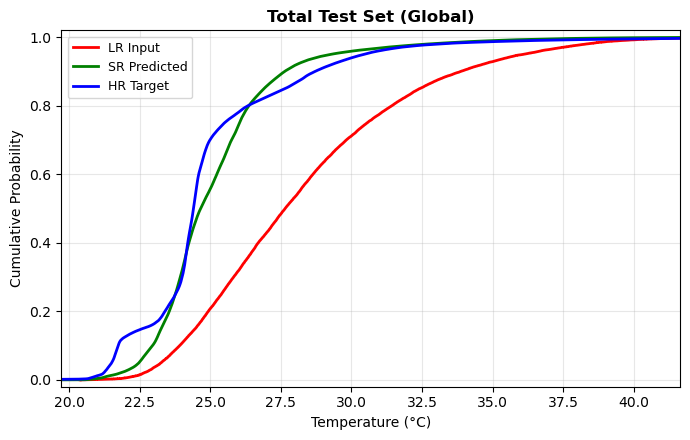

--------------------------------------------------------------------------------
Generating Individual CDFs for 3 Campaigns...


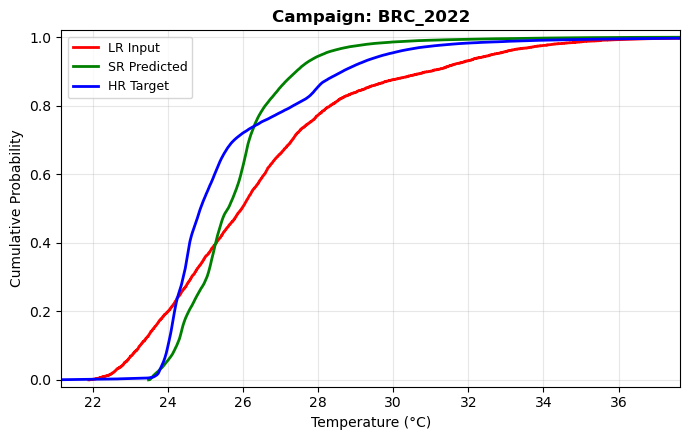

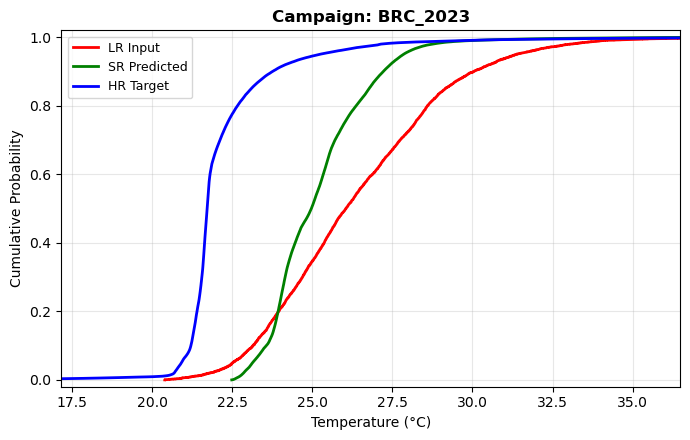

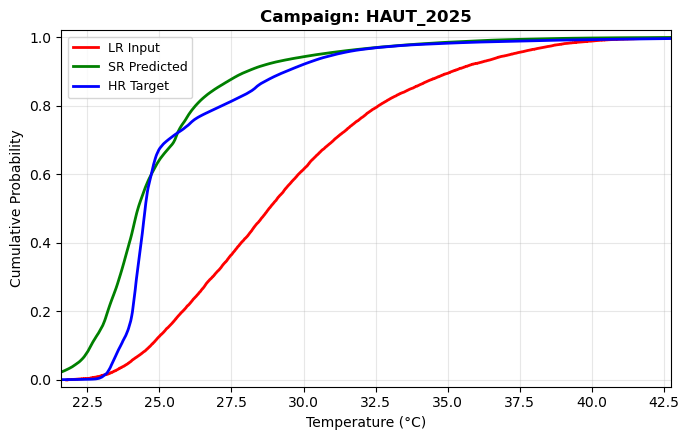

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Setup colors
palette = {"HR": "blue", "LR": "red", "SR": "green"}

# Helper function to plot a single, standalone CDF figure
def plot_standalone_cdf(lr_v, sr_v, hr_v, title_name):
    # Create an independent figure for this specific plot
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Calculate bounds based on 0.5% and 99.5% percentiles
    xmin = min(np.percentile(hr_v, 0.5), np.percentile(lr_v, 0.5)) - 1.0
    xmax = max(np.percentile(hr_v, 99.5), np.percentile(lr_v, 99.5)) + 1.0
    
    for vec, key, lbl in [(lr_v, "LR", "LR Input"),
                          (sr_v, "SR", "SR Predicted"), 
                          (hr_v, "HR", "HR Target")]:
        sorted_data = np.sort(vec)
        y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax.plot(sorted_data, y_values, color=palette[key], lw=2.0, label=lbl)
        
    ax.set_title(title_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Temperature (°C)", fontsize=10)
    ax.set_ylabel("Cumulative Probability", fontsize=10)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)
    
    plt.tight_layout()
    plt.show()  # Forces the cell to output this plot independently before moving on


# ─────────────────────────────────────────────────────────────
# 1. PLOT standalone TOTAL GLOBAL TEST SET
# ─────────────────────────────────────────────────────────────
print("Generating Global Total Test Set CDF...")

global_hr_v = hr[pure_water_mask]
global_sr_v = sr[pure_water_mask]

global_lr_v_list = []
for i in range(len(lr)):
    lr_up = np.repeat(np.repeat(lr[i], 4, axis=0), 4, axis=1)
    global_lr_v_list.append(lr_up[pure_water_mask[i]])
global_lr_v = np.concatenate(global_lr_v_list) if len(global_lr_v_list) > 0 else np.array([])

if len(global_hr_v) > 0 and len(global_lr_v) > 0:
    plot_standalone_cdf(global_lr_v, global_sr_v, global_hr_v, "Total Test Set (Global)")
else:
    print("[WARN] No global water pixels found to plot.")

print("-" * 80)


# ─────────────────────────────────────────────────────────────
# 2. PLOT standalone PER-CAMPAIGN CDFs
# ─────────────────────────────────────────────────────────────
unique_campaigns = np.unique(campaigns)
print(f"Generating Individual CDFs for {len(unique_campaigns)} Campaigns...")

for camp in unique_campaigns:
    camp_idx = (campaigns == camp)
    camp_water_mask = pure_water_mask[camp_idx]
    
    hr_v = hr[camp_idx][camp_water_mask]
    sr_v = sr[camp_idx][camp_water_mask]
    
    lr_v_list = []
    camp_lr = lr[camp_idx]
    for i in range(len(camp_lr)):
        lr_up = np.repeat(np.repeat(camp_lr[i], 4, axis=0), 4, axis=1)
        lr_v_list.append(lr_up[camp_water_mask[i]])
    lr_v = np.concatenate(lr_v_list) if len(lr_v_list) > 0 else np.array([])
    
    if len(hr_v) == 0 or len(lr_v) == 0:
        print(f"Skipping Campaign {camp}: Insufficient water pixels.")
        continue
        
    # Generate standalone figure context for this campaign run
    plot_standalone_cdf(lr_v, sr_v, hr_v, f"Campaign: {camp}")

### Time contribution to model

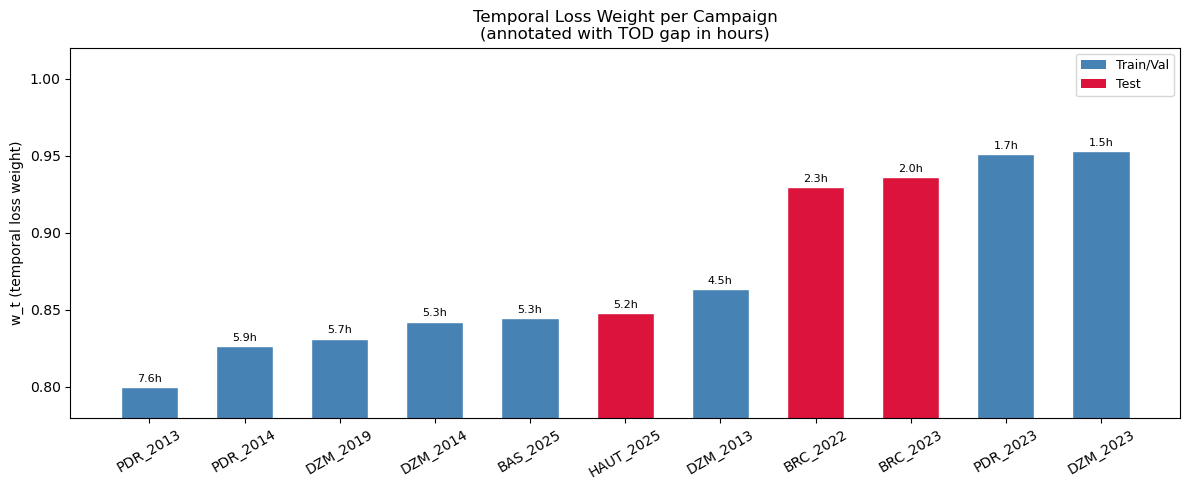

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open(METADATA_PATH) as f:
    metadata = json.load(f)

# Compute w_t per campaign (same for all patches in a campaign)
seen = {}
for key, meta in metadata.items():
    c     = meta.get("campaign")
    if c in seen:
        continue
    t_gap = float(meta.get("time_gap_hours", 0))
    d_gap = float(meta.get("date_gap_days", 0))
    w_t   = 1.0 - (0.7 * t_gap/24.0 + 0.3 * d_gap/365.0)
    w_t   = max(0.8, min(1.0, w_t))
    split = meta.get("split")
    seen[c] = {"w_t": w_t, "split": split, "tod_gap": t_gap}

# Sort by w_t
sorted_campaigns = sorted(seen.items(), key=lambda x: x[1]["w_t"])

names  = [c for c, _ in sorted_campaigns]
values = [v["w_t"] for _, v in sorted_campaigns]
colors = ["crimson" if v["split"] == "test" else "steelblue" 
          for _, v in sorted_campaigns]
tod_gaps = [v["tod_gap"] for _, v in sorted_campaigns]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, values, color=colors, edgecolor="white", width=0.6)

# Annotate TOD gap above each bar
for bar, tod in zip(bars, tod_gaps):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f"{tod:.1f}h", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("w_t (temporal loss weight)")
ax.set_title("Temporal Loss Weight per Campaign\n"
             "(annotated with TOD gap in hours)")
ax.set_ylim(0.78, 1.02)
ax.tick_params(axis="x", rotation=30)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="steelblue", label="Train/Val"),
    Patch(facecolor="crimson",   label="Test"),
], fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
import torch
import numpy as np

def get_channel_gradients(model, sample, device):
    """
    Returns mean absolute gradient per input channel [27].
    Focuses on water pixels only.
    """
    model.eval()
    
    # Build full 27-channel input
    lr     = sample["lr"].unsqueeze(0).to(device)
    aux_lr = sample["aux_lr"].unsqueeze(0).to(device)
    H, W   = lr.shape[2], lr.shape[3]
    
    def tile(v):
        return v.unsqueeze(0).to(device)[:, None, None, None].expand(1, 1, H, W)
    
    time_ch = torch.cat([
        tile(sample["lr_time"])       / 24.0,
        tile(sample["time_gap_hours"])/ 24.0,
        tile(sample["date_gap_days"]) / 365.0,
    ], dim=1)
    
    # Full input — requires grad for attribution
    x = torch.cat([lr, aux_lr, time_ch], dim=1).detach().requires_grad_(True)
    
    # Forward pass
    if model.use_spade:
        seg_mid = sample["aux_mid"].unsqueeze(0).to(device)[:, 8:22]
        seg_hr  = sample["aux_hr"].unsqueeze(0).to(device)[:, 8:22]
        out = model.net_g(x, seg_mid, seg_hr)
    else:
        out = model.net_g(x, None, None)
    
    sr = model.out_head(out)
    
    # Target — mean SR over water pixels only
    water = (sample["water_mask"].unsqueeze(0).to(device) * 
             sample["hr_mask"].unsqueeze(0).to(device)).bool()
    target = sr[water].mean() if water.sum() > 0 else sr.mean()
    target.backward()
    
    # Mean absolute gradient per channel [27]
    return x.grad[0].abs().mean(dim=(1, 2)).detach().cpu().numpy()


# Channel group definitions for easy aggregation
GROUPS = {
    "TIR":            [0],
    "Spectral":       [1, 2, 3, 4, 5],
    "Indices":        [6, 7, 8],
    "LULC":           list(range(9, 23)),
    "DEM":            [23],
    "lr_time":        [24],        # individual
    "time_gap_hours": [25],        # individual
    "date_gap_days":  [26],        # individual
}

CHANNEL_NAMES = (
    ["LR TIR"]
    + ["Blue", "Green", "Red", "NIR", "SWIR1"]
    + ["NDVI", "NDWI", "NDMI"]
    + [f"LULC_{i}" for i in range(14)]
    + ["DEM"]
    + ["lr_time"]
    + ["time_gap_hours"]
    + ["date_gap_days"]
)

In [18]:
from scripts.utils.dataset import SRDataset
test_ds = SRDataset(
    split="test",  # Pointing to the test set
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,
    aux_dir=str(PATCHES_DIR / "test" / "AUX"),
    transform=None,
)

In [25]:
# Pick one water patch per campaign
patches = {
    "BRC_2023": "BRC_2023_b0_r1024_c1024.npy",
    "BRC_2022": "BRC_2022_b0_r512_c256.npy",
    "HAUT_2025": "HAUT_2025_b0_r4608_c1536.npy",
    # "PDR_2023" : "PDR_2023_b2_r2048_c512.npy",
    # "DZM_2014" : "DZM_2014_b2_r2816_c0.npy"
}

fname_to_idx = {test_ds.files[i]: i for i in range(len(test_ds))}

results = {}
for campaign, fname in patches.items():
    sample = test_ds[fname_to_idx[fname]]
    grads  = get_channel_gradients(model, sample, device)
    total  = grads.sum()
    
    results[campaign] = {
        "grads": grads,
        "group_pct": {
            g: grads[idx].sum() / total * 100
            for g, idx in GROUPS.items()
        }
    }
    
    print(f"\n{campaign} (TOD gap: {sample['time_gap_hours'].item():.1f}h):")
    for g, pct in results[campaign]["group_pct"].items():
        marker = " ◄" if g in ("lr_time", "time_gap_hours", "date_gap_days") else ""
        print(f"  {g:20s}: {pct:.2f}%{marker}")


BRC_2023 (TOD gap: 2.0h):
  TIR                 : 3.70%
  Spectral            : 18.41%
  Indices             : 11.18%
  LULC                : 51.87%
  DEM                 : 3.71%
  lr_time             : 3.71% ◄
  time_gap_hours      : 3.70% ◄
  date_gap_days       : 3.72% ◄

BRC_2022 (TOD gap: 2.3h):
  TIR                 : 3.71%
  Spectral            : 18.42%
  Indices             : 11.14%
  LULC                : 51.85%
  DEM                 : 3.74%
  lr_time             : 3.71% ◄
  time_gap_hours      : 3.72% ◄
  date_gap_days       : 3.71% ◄

HAUT_2025 (TOD gap: 5.2h):
  TIR                 : 3.70%
  Spectral            : 18.36%
  Indices             : 11.19%
  LULC                : 51.87%
  DEM                 : 3.74%
  lr_time             : 3.71% ◄
  time_gap_hours      : 3.72% ◄
  date_gap_days       : 3.71% ◄


### Discriminator output realness map

In [ ]:
import sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

# ==========================================
# 1. PATHS & INITIALIZATION
# ==========================================
BASE          = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
MODEL_PATH    = BASE / "checkpoints/gan_final/exp2_fixed_lr_schedule_epoch=56_val_water_mae=0.8773.ckpt"

sys.path.insert(0, str(BASE))

from scripts.models.realesrgan import RealESRGANModule
from scripts.utils.dataset import SRDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load dataset normalization statistics
with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN = stats_data["hr"]["mean"]
HR_STD  = stats_data["hr"]["std"]

# ==========================================
# 2. LOAD MODEL & DATASETS
# ==========================================
print("Loading model checkpoint...")
model = RealESRGANModule.load_from_checkpoint(MODEL_PATH, strict=False).to(device).eval()

print("Initializing datasets...")
val_ds = SRDataset(
    split="val",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,                
    aux_dir=str(PATCHES_DIR / "val" / "AUX"),
    transform=None,
)

# Optional: Add train or test sets if you want to search across all splits
dataset_splits = {
    "val": val_ds,
}

# ==========================================
# 3. REALNESS MAP GENERATION FUNCTION
# ==========================================
def generate_and_save_realness_maps(model_obj, sample, save_prefix="realness_map"):
    """
    Passes a sample through the Generator and Discriminator, extracts pixel-wise
    realness scores, applies the valid HR mask, and saves side-by-side visualizations.
    """
    model_obj.eval()

    # Build input batch tensor on device
    batch = {
        "lr": sample["lr"].unsqueeze(0).to(device),
        "aux_lr": sample["aux_lr"].unsqueeze(0).to(device),
        "aux_mid": sample["aux_mid"].unsqueeze(0).to(device),
        "aux_hr": sample["aux_hr"].unsqueeze(0).to(device),
        "time_channels": sample["time_channels"].unsqueeze(0).to(device),
        "time_gap_hours": sample["time_gap_hours"].unsqueeze(0).to(device),
        "date_gap_days": sample["date_gap_days"].unsqueeze(0).to(device),
    }

    hr_gt = sample["hr"].unsqueeze(0).to(device)
    hr_mask = sample["hr_mask"].squeeze().numpy()
    valid = hr_mask > 0.5  # Mask for valid flight path / water pixels

    # Locate discriminator module in the Lightning Wrapper
    discriminator = getattr(model_obj, 'discriminator', getattr(model_obj, 'net_d', None))
    if discriminator is None:
        raise AttributeError("Could not locate discriminator module (`net_d` or `discriminator`) in model.")

    with torch.no_grad():
        # 1. Forward pass through Generator
        sr_tensor = model_obj(batch)  # Output shape: [1, 1, H, W]

        # 2. Prepare 3-channel input for Discriminator (Thermal 1-ch + AUX_HR 2-ch)
        if sr_tensor.shape[1] == 1 and batch["aux_hr"].shape[1] == 2:
            disc_input_sr = torch.cat([sr_tensor, batch["aux_hr"]], dim=1)
            disc_input_hr = torch.cat([hr_gt, batch["aux_hr"]], dim=1)
        else:
            disc_input_sr = sr_tensor.repeat(1, 3, 1, 1)
            disc_input_hr = hr_gt.repeat(1, 3, 1, 1)

        # 3. Forward pass through Discriminator
        raw_scores_sr = discriminator(disc_input_sr)
        raw_scores_hr = discriminator(disc_input_hr)

    # Convert output feature maps to NumPy 2D arrays
    scores_sr = raw_scores_sr.detach().cpu().squeeze().numpy()
    scores_hr = raw_scores_hr.detach().cpu().squeeze().numpy()

    # Joint min-max normalization across valid regions
    valid_sr = scores_sr[valid] if scores_sr.shape == valid.shape else scores_sr
    valid_hr = scores_hr[valid] if scores_hr.shape == valid.shape else scores_hr

    combined_min = min(valid_sr.min(), valid_hr.min())
    combined_max = max(valid_sr.max(), valid_hr.max())

    norm_sr = (scores_sr - combined_min) / (combined_max - combined_min + 1e-8)
    norm_hr = (scores_hr - combined_min) / (combined_max - combined_min + 1e-8)

    # Apply invalid mask (set non-flight/land pixels to NaN)
    if norm_sr.shape == valid.shape:
        norm_sr = np.where(valid, norm_sr, np.nan)
        norm_hr = np.where(valid, norm_hr, np.nan)

    # Render color-mapped figures
    cmap = cm.get_cmap('jet')
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(norm_sr, cmap=cmap, vmin=0, vmax=1)
    axes[0].set_title("SR Pixel-wise Realness Map $D(G(x))$")
    axes[0].axis("off")

    im1 = axes[1].imshow(norm_hr, cmap=cmap, vmin=0, vmax=1)
    axes[1].set_title("Ground Truth (HR) Realness Map $D(y)$")
    axes[1].axis("off")

    cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.8)
    cbar.set_label("Discriminator Realness Score (0 = Low/Fake, 1 = High/Real)")

    save_fig_path = f"{save_prefix}_comparison.png"
    plt.savefig(save_fig_path, bbox_inches='tight', dpi=300)
    plt.close()

    print(f"[SUCCESS] Realness map figure saved to: {save_fig_path}")

# ==========================================
# 4. TARGET FILE LOOKUP & EXECUTION
# ==========================================
def process_target_file(target_fname):
    target_clean = target_fname.replace(".npy", "").replace(".tif", "")
    found_sample = None
    found_split = None

    print(f"\nSearching for patch: '{target_fname}'...")
    for split_name, ds in dataset_splits.items():
        if ds is None:
            continue
        for i in range(len(ds)):
            sample_fname = ds[i]["fname"]
            if target_clean in sample_fname:
                found_sample = ds[i]
                found_split = split_name
                print(f"Found in '{split_name}' dataset at index {i}.")
                break
        if found_sample is not None:
            break

    if found_sample is None:
        raise FileNotFoundError(f"Could not locate sample '{target_fname}' in provided dataset splits.")

    save_prefix = f"realness_{found_split}_{target_clean}"
    generate_and_save_realness_maps(model, found_sample, save_prefix=save_prefix)

if __name__ == "__main__":
    TARGET_FILE = "PDR_2013_b1_r1536_c512.npy"
    process_target_file(TARGET_FILE)

Using device: cuda
Loading model checkpoint...
[INFO] generator loaded 702 params
[INFO] discriminator loaded 28 params


/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:193: Found keys that are in the model state dict but not in the checkpoint: ['net_g.net.conv_first.weight', 'net_g.net.conv_first.bias', 'net_g.net.body.0.rdb1.conv1.weight', 'net_g.net.body.0.rdb1.conv1.bias', 'net_g.net.body.0.rdb1.conv2.weight', 'net_g.net.body.0.rdb1.conv2.bias', 'net_g.net.body.0.rdb1.conv3.weight', 'net_g.net.body.0.rdb1.conv3.bias', 'net_g.net.body.0.rdb1.conv4.weight', 'net_g.net.body.0.rdb1.conv4.bias', 'net_g.net.body.0.rdb1.conv5.weight', 'net_g.net.body.0.rdb1.conv5.bias', 'net_g.net.body.0.rdb2.conv1.weight', 'net_g.net.body.0.rdb2.conv1.bias', 'net_g.net.body.0.rdb2.conv2.weight', 'net_g.net.body.0.rdb2.conv2.bias', 'net_g.net.body.0.rdb2.conv3.weight', 'net_g.net.body.0.rdb2.conv3.bias', 'net_g.net.body.0.rdb2.conv4.weight', 'net_g.net.body.0.rdb2.conv4.bias', 'net_g.net.body.0.rdb2.conv5.weight', 'net_g.net.body.0.rdb2.conv5.bias', 'net_g.net.body.0.rdb3.

Initializing datasets...

Searching for patch: 'PDR_2013_b1_r1536_c512.npy'...
Found in 'val' dataset at index 30.


/tmp/ipykernel_3503885/2908873822.py:120: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


[SUCCESS] Realness map figure saved to: realness_val_PDR_2013_b1_r1536_c512_comparison.png
